# Sewer Signals — Exploratory Data Analysis

**Goal**: Understand the structure, quality, and statistical properties of two CDC datasets
before any modelling work. We follow a two-pass strategy:

1. Filter to **California** and run a full EDA.
2. Narrow further to the **9 Bay Area counties** and repeat the key checks.

Working through EDA in this order lets us see the California baseline first so that
Bay Area anomalies stand out clearly rather than being invisible against a national backdrop.

**Datasets**
| # | File | Total rows | Granularity | Key metric |
|---|------|-----------|-------------|------------|
| 1 | `CDC_Wastewater_Data_for_SARS-CoV-2_20260505.csv` | ~567 k | One row per wastewater **sample** | `pcr_target_avg_conc` (copies/L) |
| 2 | `Weekly_United_States_COVID-19_Cases_and_Deaths_by_County_-_ARCHIVED_20260502.csv` | ~566 k | One row per **county × week** | `new_cases`, `new_deaths` |

> **Note on units (Dataset 1)**: Three measurement units co-exist in the data:
> `copies/l wastewater`, `copies/g dry sludge`, and `log10 copies/l wastewater`.
> These are not directly comparable. We identify each and restrict quantitative
> analysis to a single unit family after the initial audit.

## 0  Setup

In [151]:
import warnings
warnings.filterwarnings('ignore')

import sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 4)})

ROOT = pathlib.Path('..').resolve()
sys.path.insert(0, str(ROOT))
RAW = ROOT / 'data' / 'raw'

WW_FILE    = RAW / 'CDC_Wastewater_Data_for_SARS-CoV-2_20260505.csv'
CASES_FILE = RAW / 'Weekly_United_States_COVID-19_Cases_and_Deaths_by_County_-_ARCHIVED_20260502.csv'

from src.config import BAY_AREA_FIPS, FIPS_TO_COUNTY

# Config stores FIPS without leading zero; the raw data uses zero-padded 5-digit strings.
# We maintain a zero-padded set for matching against the raw CSVs.
BAY_FIPS_PADDED = {f.zfill(5) for f in BAY_AREA_FIPS.values()}
# Map from zero-padded FIPS -> county name for display
FIPS_TO_NAME = {f.zfill(5): name for f, name in FIPS_TO_COUNTY.items()}

print('Bay Area FIPS (zero-padded):', sorted(BAY_FIPS_PADDED))

Bay Area FIPS (zero-padded): ['06001', '06013', '06041', '06055', '06075', '06081', '06085', '06095', '06097']


---
## 1  Dataset 1 — CDC Wastewater Sample Data for SARS-CoV-2

Unlike aggregate NWSS files, this dataset operates at the **individual sample** level:
each row is a single PCR measurement from a sampling site on a given date.
That granularity gives us raw concentration values and full QC metadata, but it also
means multiple rows can exist for the same site and date (e.g., duplicate gene targets,
replicate extractions).

Key columns we will focus on:

| Column | Description |
|--------|-------------|
| `site` | Anonymous plant ID (consistent over time) |
| `state_territory` | 2-letter abbreviation (lowercase in this file) |
| `county_fips` | Zero-padded 5-digit FIPS; multi-county sites use comma-separated values |
| `population_served` | Estimated persons served (comma-formatted string in raw data) |
| `sample_collect_date` | Date of collection (YYYY-MM-DD) |
| `pcr_target_avg_conc` | Mean concentration across PCR replicates (comma-formatted) |
| `pcr_target_units` | Unit of concentration — three distinct units coexist |
| `pcr_target_detect` | Boolean detection flag (`yes` / `no`) |
| `lod_sewage` | Limit of detection (same unit as `pcr_target_avg_conc`) |
| `rec_eff_percent` | Recovery efficiency (%) — a key QC indicator |
| `inhibition_detect` | Whether PCR inhibition was detected (`yes` / `no`) |
| `source` | Reporting entity: `State_Territory`, `CDC_Verily`, `CDC_Biobot`, `WastewaterSCAN` |

### 1.1  Load & California filter

In [152]:
# Read all columns as strings first so we can inspect raw formatting
# (pcr_target_avg_conc and population_served have comma-formatted numbers)
# before applying numeric coercions.
ww_raw = pd.read_csv(WW_FILE, dtype=str, low_memory=False)

print(f'Full dataset shape : {ww_raw.shape}')
print(f'Columns            : {list(ww_raw.columns)}')

Full dataset shape : (566793, 38)
Columns            : ['record_id', 'site', 'state_territory', 'source', 'county_fips', 'counties_served', 'population_served', 'sample_id', 'sample_collect_date', 'sample_type', 'sample_matrix', 'sample_location', 'flow_rate', 'concentration_method', 'pasteurized', 'pcr_type', 'extraction_method', 'major_lab_method', 'inhibition_detect', 'inhibition_adjust', 'ntc_amplify', 'pcr_target', 'pcr_gene_target_agg', 'pcr_target_avg_conc', 'pcr_target_units', 'lod_sewage', 'pcr_target_detect', 'pcr_target_avg_conc_lin', 'pcr_target_flowpop_lin', 'pcr_target_mic_lin', 'hum_frac_target_mic', 'hum_frac_mic_conc', 'hum_frac_mic_unit', 'rec_eff_percent', 'rec_eff_target_name', 'rec_eff_spike_matrix', 'rec_eff_spike_conc', 'date_updated']


In [153]:
# state_territory is lowercase in this file ('ca', not 'CA')
ww_ca = ww_raw[ww_raw['state_territory'] == 'ca'].copy()

print(f'California rows    : {len(ww_ca):,}  ({len(ww_ca) / len(ww_raw) * 100:.1f}% of national)')
print(f'Unique sites (CA)  : {ww_ca["site"].nunique()}')
print(f'Unique sources     : {sorted(ww_ca["source"].unique())}')

California rows    : 63,539  (11.2% of national)
Unique sites (CA)  : 116
Unique sources     : ['CDC_Biobot', 'CDC_Verily', 'State_Territory', 'WastewaterSCAN']


In [154]:
# --- Numeric coercions ---
# The raw CSV stores several numeric fields as comma-formatted strings (e.g. "689,905.7").
# We strip commas before converting to float.

def strip_commas(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series.str.replace(',', '', regex=False), errors='coerce')

for col in ['pcr_target_avg_conc', 'pcr_target_avg_conc_lin',
            'pcr_target_flowpop_lin', 'pcr_target_mic_lin',
            'lod_sewage', 'rec_eff_percent', 'population_served',
            'flow_rate', 'hum_frac_mic_conc']:
    if col in ww_ca.columns:
        ww_ca[col] = strip_commas(ww_ca[col])

ww_ca['sample_collect_date'] = pd.to_datetime(ww_ca['sample_collect_date'], errors='coerce')

print(f'Date range: {ww_ca["sample_collect_date"].min().date()} -> '
      f'{ww_ca["sample_collect_date"].max().date()}')

Date range: 2020-03-18 -> 2026-04-28


### 1.2  Unit audit

Three measurement units coexist in `pcr_target_units`. We must not mix them in
any statistical summary because their scales differ by orders of magnitude.
We audit their relative frequency and data quality before deciding which to keep.

In [155]:
unit_summary = (
    ww_ca.groupby('pcr_target_units')
    .agg(
        n_rows=('record_id', 'count'),
        n_sites=('site', 'nunique'),
        pct_detected=('pcr_target_detect', lambda s: (s == 'yes').mean() * 100),
        conc_median=('pcr_target_avg_conc', 'median'),
        conc_min=('pcr_target_avg_conc', 'min'),
        conc_max=('pcr_target_avg_conc', 'max'),
    )
    .reset_index()
    .assign(row_pct=lambda d: (d['n_rows'] / len(ww_ca) * 100).round(1))
    .sort_values('n_rows', ascending=False)
)
display(unit_summary.round(2))

# The dominant unit family in copies/l wastewater is what the modelling pipeline
# expects. We restrict subsequent quantitative EDA to that unit.
# copies/g dry sludge comes from sludge (solid fraction) sampling -- a different
# matrix that requires separate normalisation logic.
# log10 copies/l is a pre-transformed version of copies/l; we keep linear values
# and apply log-transforms ourselves for consistency.

,pcr_target_units,n_rows,n_sites,pct_detected,conc_median,conc_min,conc_max,row_pct
0,copies/g dry sludge,36105,68,97.50,82141.88,0.0,19966665.81,56.8
1,copies/l wastewater,26270,80,97.18,104756.08,0.0,86500000.00,41.3
2,log10 copies/l wastewater,1164,9,97.94,4.82,0.0,6.72,1.8


In [156]:
# Restrict to liquid wastewater (copies/l) for the rest of the CA analysis.
# This is the unit aligned with the modelling target (log1p_concentration in config.py).
ww_ca_liq = ww_ca[ww_ca['pcr_target_units'] == 'copies/l wastewater'].copy()
print(f'Rows after unit filter: {len(ww_ca_liq):,}  '
      f'({len(ww_ca_liq)/len(ww_ca)*100:.1f}% of CA)')

Rows after unit filter: 26,270  (41.3% of CA)


### 1.3  Data types & basic info

In [157]:
ww_ca_liq.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26270 entries, 1 to 566785
Data columns (total 38 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   record_id                26270 non-null  object        
 1   site                     26270 non-null  object        
 2   state_territory          26270 non-null  object        
 3   source                   26270 non-null  object        
 4   county_fips              26270 non-null  object        
 5   counties_served          26270 non-null  object        
 6   population_served        26270 non-null  int64         
 7   sample_id                26270 non-null  object        
 8   sample_collect_date      26270 non-null  datetime64[ns]
 9   sample_type              26270 non-null  object        
 10  sample_matrix            26270 non-null  object        
 11  sample_location          26270 non-null  object        
 12  flow_rate                23112 non-n

In [158]:
# Cardinality overview for categorical columns.
# Understanding how many unique values each categorical has guides
# decisions about groupby aggregation and encoding strategies.
cat_cols = ['source', 'sample_location', 'pcr_type', 'pcr_gene_target_agg',
            'inhibition_detect', 'ntc_amplify', 'pasteurized', 'major_lab_method']

for col in cat_cols:
    if col in ww_ca_liq.columns:
        vc = ww_ca_liq[col].value_counts(dropna=False)
        print(f'\n{col} ({len(vc)} unique):')
        print(vc.to_string())


source (3 unique):
source
State_Territory    16782
CDC_Verily          6469
CDC_Biobot          3019

sample_location (2 unique):
sample_location
wwtp        22872
upstream     3398

pcr_type (2 unique):
pcr_type
ddpcr    22307
qpcr      3963

pcr_gene_target_agg (3 unique):
pcr_gene_target_agg
n1       16124
n         6469
n2,n1     3677

inhibition_detect (3 unique):
inhibition_detect
not tested    15561
no            10427
yes             282

ntc_amplify (1 unique):
ntc_amplify
no    26270

pasteurized (3 unique):
pasteurized
no     21903
yes     3369
NaN      998

major_lab_method (5 unique):
major_lab_method
1      15434
2       6469
4       2602
999      998
5        767


### 1.4  Statistical summary

In [159]:
num_summary_cols = [
    'pcr_target_avg_conc', 'lod_sewage',
    'rec_eff_percent', 'flow_rate', 'population_served',
]
num_summary_cols = [c for c in num_summary_cols if c in ww_ca_liq.columns]

ww_ca_liq[num_summary_cols].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
pcr_target_avg_conc,26270.0,389965.406,1306912.063,0.0,29557.181,104756.083,335904.425,86500000.0
lod_sewage,26270.0,5366.698,32035.883,4.0,1000.000,1000.000,1500.000,500000.0
rec_eff_percent,26270.0,69.787,32.122,-1.0,54.300,68.099,83.000,2050.0
flow_rate,23112.0,39.850,73.026,0.0,3.000,7.790,30.200,673.0
population_served,26270.0,495460.164,981928.765,3882.0,28000.000,75000.000,279023.000,4000000.0


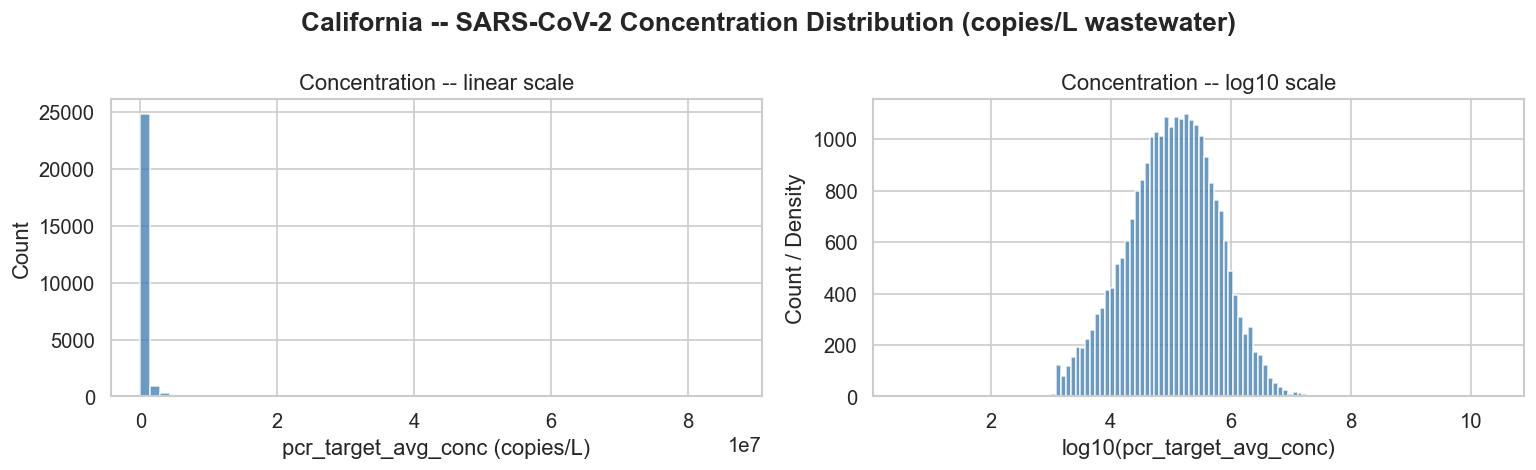

In [160]:
# The concentration values span many orders of magnitude (sub-1 to millions of copies/L).
# A log10 histogram is much more interpretable than a linear one for this kind of
# right-skewed, multiplicative measurement.

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: raw concentration on linear scale (shows how extreme the skew is)
ax = axes[0]
data = ww_ca_liq['pcr_target_avg_conc'].dropna().clip(lower=0)
ax.hist(data, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('pcr_target_avg_conc (copies/L)')
ax.set_ylabel('Count')
ax.set_title('Concentration -- linear scale')

# Right: log10 scale -- symmetric, bell-shaped if log-normal
ax = axes[1]
log_data = np.log10(data.replace(0, np.nan).dropna())
ax.hist(log_data, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
log_data.plot.kde(ax=ax, color='navy', lw=1.5, secondary_y=False)
ax.set_xlabel('log10(pcr_target_avg_conc)')
ax.set_ylabel('Count / Density')
ax.set_title('Concentration -- log10 scale')

fig.suptitle('California -- SARS-CoV-2 Concentration Distribution (copies/L wastewater)',
             fontweight='bold')
plt.tight_layout()
plt.show()

# A log-normal distribution here would support using log1p as the modelling target,
# which is what config.py specifies (TARGET_COL = 'log1p_concentration').

In [161]:
# Detection rate by source -- different data providers may have different
# assay sensitivities or reporting conventions, which can create systematic
# batch effects if we merge naively without accounting for source.
detect_by_source = (
    ww_ca_liq.groupby('source')
    .apply(lambda g: pd.Series({
        'n_samples'   : len(g),
        'pct_detected': round((g['pcr_target_detect'] == 'yes').mean() * 100, 1),
        'median_conc' : round(g.loc[g['pcr_target_detect'] == 'yes', 'pcr_target_avg_conc'].median(), 1),
    }))
    .reset_index()
)
display(detect_by_source)

,source,n_samples,pct_detected,median_conc
0,CDC_Biobot,3019.0,99.9,895989.2
1,CDC_Verily,6469.0,94.7,37674.8
2,State_Territory,16782.0,97.6,125074.6


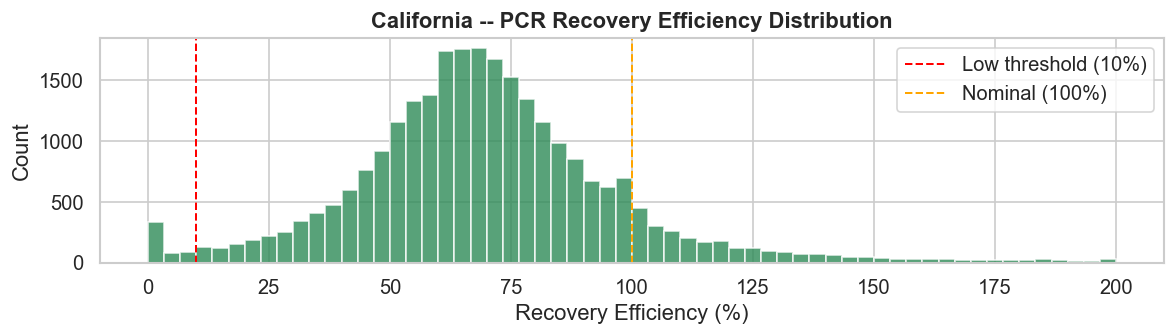

Samples with rec_eff_percent < 10%: 493 (1.9%)


In [162]:
# Recovery efficiency distribution -- rec_eff_percent should ideally be near 100%.
# Very low values (<10%) indicate poor extraction and unreliable concentration readings.
fig, ax = plt.subplots(figsize=(10, 3))
ww_ca_liq['rec_eff_percent'].dropna().clip(0, 200).hist(
    bins=60, ax=ax, color='seagreen', edgecolor='white', alpha=0.8)
ax.axvline(10,  color='red',    ls='--', lw=1.2, label='Low threshold (10%)')
ax.axvline(100, color='orange', ls='--', lw=1.2, label='Nominal (100%)')
ax.set_xlabel('Recovery Efficiency (%)')
ax.set_ylabel('Count')
ax.set_title('California -- PCR Recovery Efficiency Distribution', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

low_rec = (ww_ca_liq['rec_eff_percent'] < 10).sum()
print(f'Samples with rec_eff_percent < 10%: {low_rec:,} ({low_rec/len(ww_ca_liq)*100:.1f}%)')

### 1.5  Missing value analysis

We distinguish between **structural missingness** (columns intentionally not collected
by all labs, e.g. `inhibition_adjust`) and **incidental missingness** (values that
should be present but aren't). Only the latter requires imputation.

In [163]:
missing = (
    ww_ca_liq.isnull().sum()
             .to_frame('missing_count')
             .assign(pct=lambda d: (d['missing_count'] / len(ww_ca_liq) * 100).round(1))
             .sort_values('pct', ascending=False)
)
# Show all columns with at least 1% missingness
display(missing[missing['pct'] > 1])

,missing_count,pct
inhibition_adjust,15926,60.6
flow_rate,3158,12.0
pcr_target_flowpop_lin,3159,12.0
pasteurized,998,3.8
hum_frac_mic_unit,732,2.8
hum_frac_mic_conc,732,2.8
pcr_target_mic_lin,732,2.8
hum_frac_target_mic,720,2.7
rec_eff_target_name,543,2.1
rec_eff_spike_conc,543,2.1


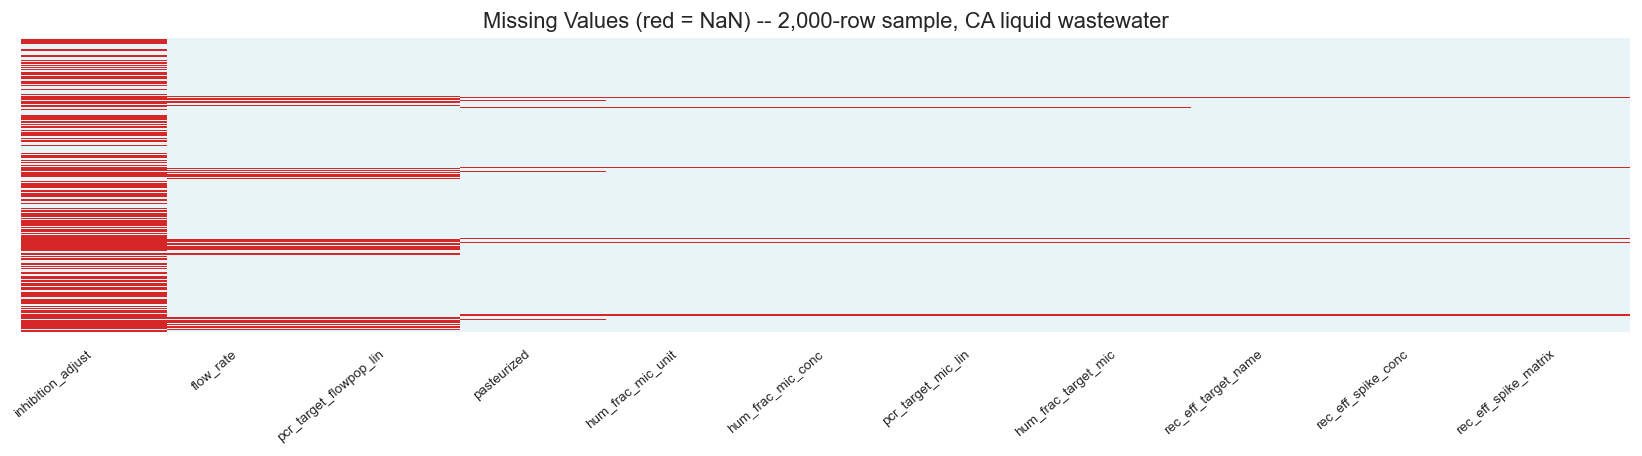

In [164]:
# Visual heatmap on a random sample -- reveals whether missing values cluster
# by rows (whole-record missingness) or by column (field-level gaps).
import random
random.seed(42)
sample_idx = sorted(random.sample(range(len(ww_ca_liq)), min(2000, len(ww_ca_liq))))
sample_df  = ww_ca_liq.iloc[sample_idx]

# Only plot columns with some missingness to keep the chart readable
missing_cols = missing[missing['pct'] > 0].index.tolist()

if missing_cols:
    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(
        sample_df[missing_cols].isnull().astype(int),
        cbar=False, yticklabels=False,
        cmap=['#e8f4f8', '#d62728'], ax=ax
    )
    ax.set_title('Missing Values (red = NaN) -- 2,000-row sample, CA liquid wastewater')
    plt.xticks(rotation=40, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print('No missing values in this subset.')

Sampling gaps > 30 days: 34 across 29 sites


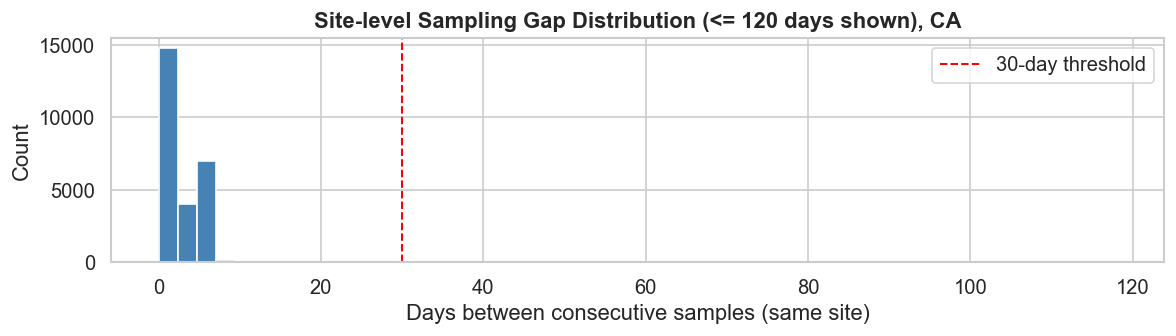

In [165]:
# Temporal gap analysis per site.
# For each site we compute the number of days between consecutive sample dates.
# Gaps > 30 days suggest the plant was temporarily offline or not reporting.
gaps = (
    ww_ca_liq.sort_values(['site', 'sample_collect_date'])
             .groupby('site')['sample_collect_date']
             .apply(lambda s: s.diff().dt.days)
             .reset_index(level=0, drop=True)
)
long_gaps = gaps[gaps > 30]
print(f'Sampling gaps > 30 days: {len(long_gaps):,} '
      f'across {ww_ca_liq.loc[long_gaps.index, "site"].nunique()} sites')

fig, ax = plt.subplots(figsize=(10, 3))
gaps[gaps <= 120].dropna().hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(30, color='red', ls='--', lw=1.2, label='30-day threshold')
ax.set_xlabel('Days between consecutive samples (same site)')
ax.set_ylabel('Count')
ax.set_title('Site-level Sampling Gap Distribution (<= 120 days shown), CA', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 1.6  QC flag analysis

This dataset contains several QC flags absent from aggregate NWSS files.
We check how often each flag is raised and whether flagged samples tend to show
systematically different concentrations -- which would motivate filtering or weighting
them differently during data engineering.

In [166]:
qc_flags = ['inhibition_detect', 'ntc_amplify']

for flag in qc_flags:
    if flag not in ww_ca_liq.columns:
        continue
    vc = ww_ca_liq[flag].value_counts(dropna=False)
    flag_rate = (ww_ca_liq[flag] == 'yes').mean() * 100
    print(f'{flag}:  {flag_rate:.1f}% positive')
    print(vc.to_string(), '\n')

inhibition_detect:  1.1% positive
inhibition_detect
not tested    15561
no            10427
yes             282 

ntc_amplify:  0.0% positive
ntc_amplify
no    26270 



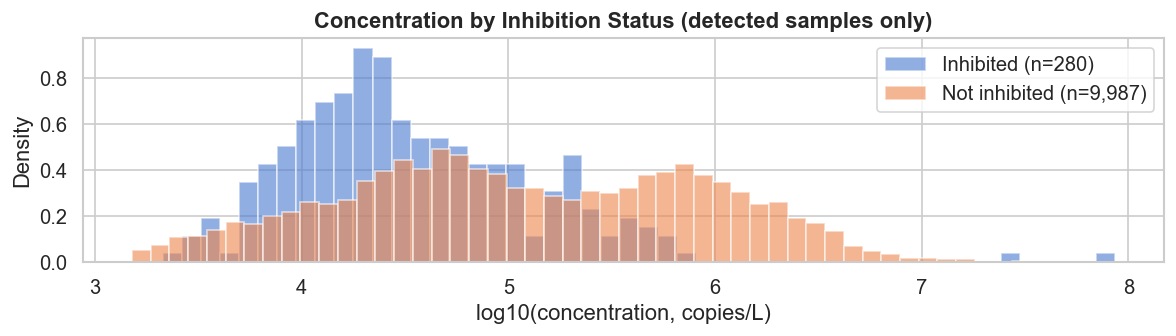

In [167]:
# Do inhibited samples have systematically lower concentrations?
# Inhibition suppresses PCR signal, so we expect inhibited samples to under-report
# the true concentration -- a directional bias, not random noise.
if 'inhibition_detect' in ww_ca_liq.columns:
    inh_groups = {
        label: ww_ca_liq.loc[
            (ww_ca_liq['inhibition_detect'] == flag) &
            (ww_ca_liq['pcr_target_detect'] == 'yes'),
            'pcr_target_avg_conc'
        ].dropna()
        for flag, label in [('yes', 'Inhibited'), ('no', 'Not inhibited')]
    }

    fig, ax = plt.subplots(figsize=(10, 3))
    for label, data in inh_groups.items():
        log_d = np.log10(data.clip(lower=0.01))
        log_d.hist(bins=50, ax=ax, alpha=0.6, label=f'{label} (n={len(data):,})',
                   density=True, edgecolor='white')
    ax.set_xlabel('log10(concentration, copies/L)')
    ax.set_ylabel('Density')
    ax.set_title('Concentration by Inhibition Status (detected samples only)', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

### 1.7  Time-series exploration -- California

We aggregate to weekly medians across all California liquid-wastewater sites to
see the epidemic wave structure. Using the **median** (rather than mean) is important
here: a handful of high-shedding sites can otherwise dominate the signal.
We show detection rate alongside concentration to see how these two dimensions
of signal strength move together.

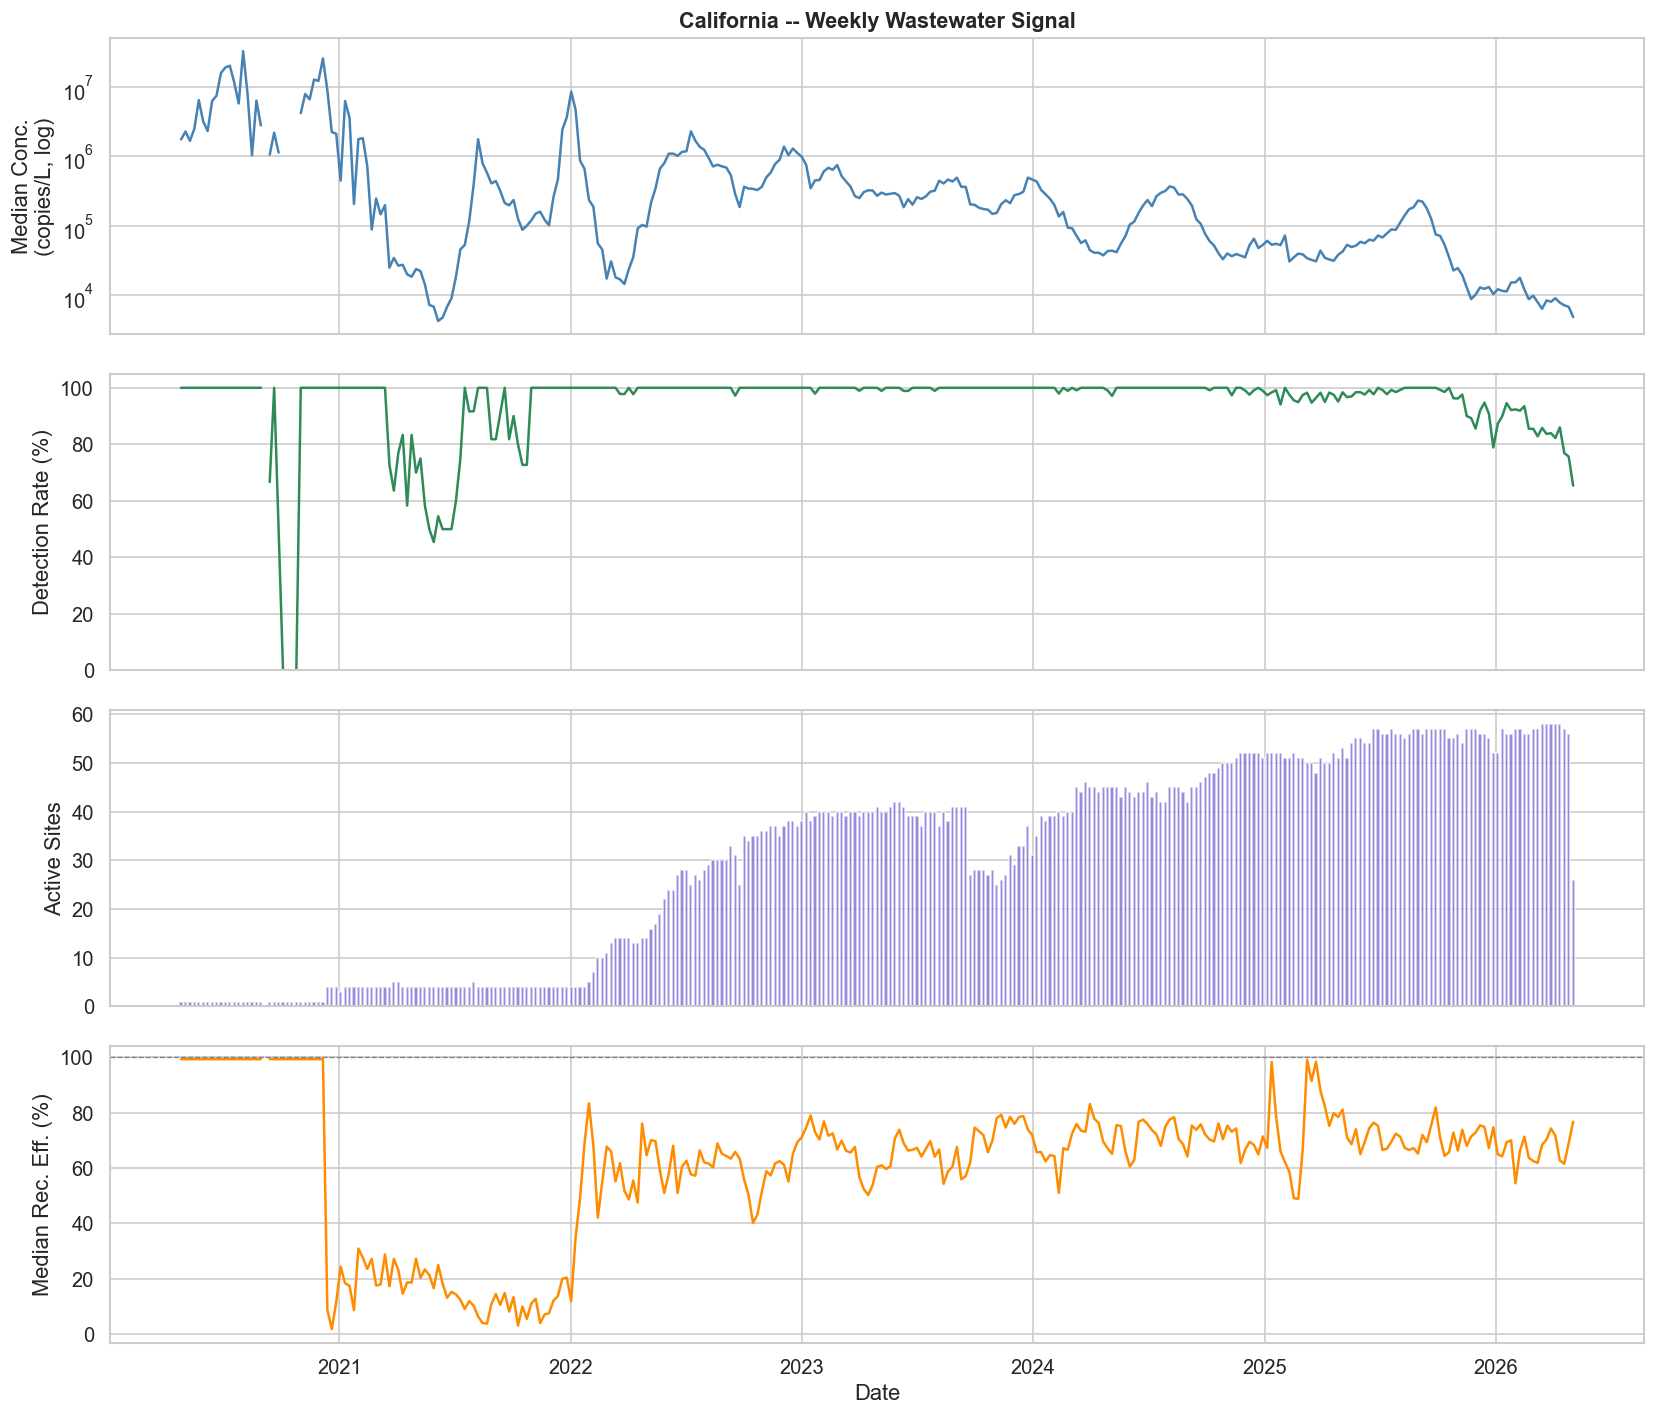

In [168]:
# Keep only WWTP samples (not upstream) for the state-level aggregate
# to avoid double-counting the same wastewater upstream and downstream.
ww_ca_wwtp = ww_ca_liq[ww_ca_liq['sample_location'] == 'wwtp']

ca_weekly = (
    ww_ca_wwtp
    .set_index('sample_collect_date')
    .resample('W')
    .agg(
        median_conc    = ('pcr_target_avg_conc', lambda s: s[s > 0].median()),
        pct_detected   = ('pcr_target_detect',   lambda s: (s == 'yes').mean() * 100),
        n_samples      = ('record_id',            'count'),
        n_active_sites = ('site',                 'nunique'),
        median_rec_eff = ('rec_eff_percent',      'median'),
    )
    .reset_index()
)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

ax = axes[0]
ax.semilogy(ca_weekly['sample_collect_date'], ca_weekly['median_conc'],
            color='steelblue', lw=1.5)
ax.set_ylabel('Median Conc.\n(copies/L, log)')
ax.set_title('California -- Weekly Wastewater Signal', fontweight='bold', fontsize=13)

ax = axes[1]
ax.plot(ca_weekly['sample_collect_date'], ca_weekly['pct_detected'],
        color='seagreen', lw=1.5)
ax.set_ylim(0, 105)
ax.set_ylabel('Detection Rate (%)')

ax = axes[2]
ax.bar(ca_weekly['sample_collect_date'], ca_weekly['n_active_sites'],
       width=5, color='slateblue', alpha=0.7)
ax.set_ylabel('Active Sites')

ax = axes[3]
ax.plot(ca_weekly['sample_collect_date'], ca_weekly['median_rec_eff'],
        color='darkorange', lw=1.5)
ax.axhline(100, color='grey', ls='--', lw=0.8)
ax.set_ylabel('Median Rec. Eff. (%)')
ax.set_xlabel('Date')

plt.tight_layout()
plt.show()

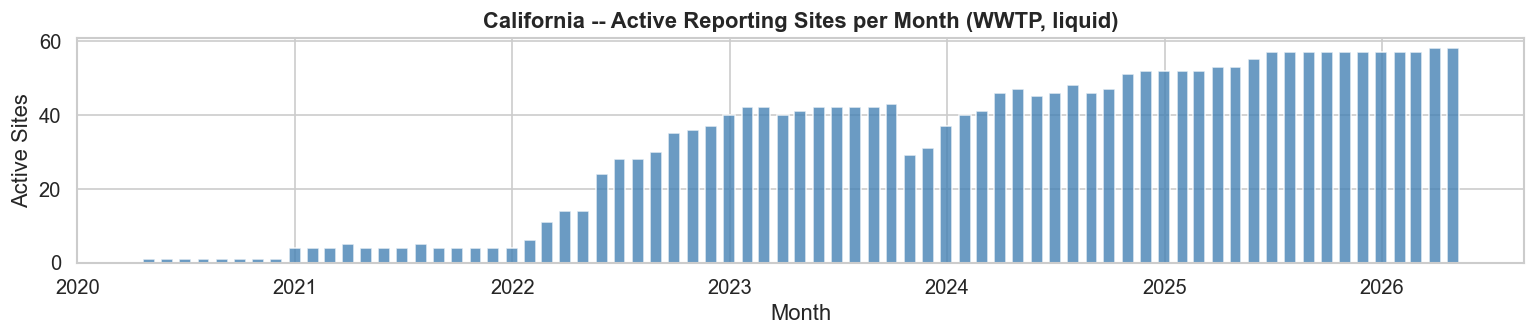

In [169]:
# Active site count per month -- thin coverage periods mean the state aggregate
# is less representative and more sensitive to individual site behavior.
monthly_sites = (
    ww_ca_wwtp
    .set_index('sample_collect_date')
    .resample('ME')['site']
    .nunique()
    .reset_index()
    .rename(columns={'site': 'active_sites'})
)

fig, ax = plt.subplots(figsize=(13, 3))
ax.bar(monthly_sites['sample_collect_date'], monthly_sites['active_sites'],
       width=20, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('Month')
ax.set_ylabel('Active Sites')
ax.set_title('California -- Active Reporting Sites per Month (WWTP, liquid)', fontweight='bold')
plt.tight_layout()
plt.show()

### 1.8  Population-served distribution

Total population served (CA, all sites): 20,027,998
Sites with population data             : 80
Sites missing population data          : 0


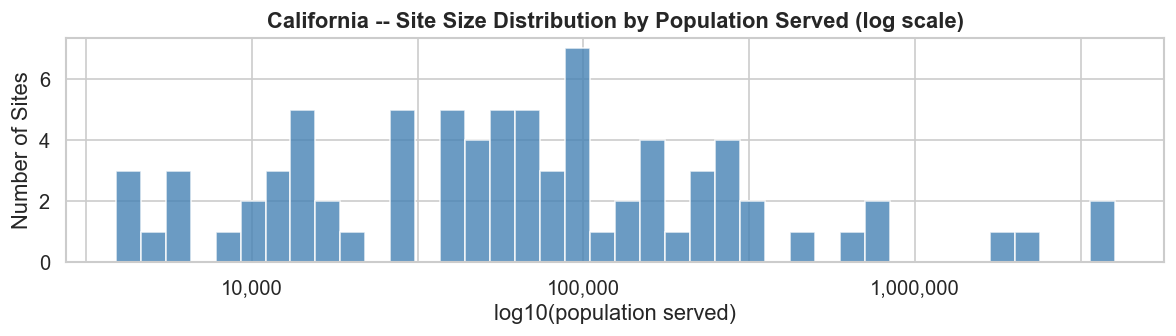

In [170]:
# Population served varies widely across sites -- this is critical for the
# population-weighted aggregation step in the data pipeline.
# We use the maximum reported value per site as a stable size estimate.
pop_per_site = (
    ww_ca_liq.groupby('site')['population_served'].max().reset_index()
)

print(f'Total population served (CA, all sites): {pop_per_site["population_served"].sum():,.0f}')
print(f'Sites with population data             : {pop_per_site["population_served"].notna().sum()}')
print(f'Sites missing population data          : {pop_per_site["population_served"].isna().sum()}')

fig, ax = plt.subplots(figsize=(10, 3))
log_pop = np.log10(pop_per_site['population_served'].replace(0, np.nan).dropna())
ax.hist(log_pop, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('log10(population served)')
ax.set_ylabel('Number of Sites')
ax.set_title('California -- Site Size Distribution by Population Served (log scale)',
             fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'{10**v:,.0f}' if v == int(v) else ''))
plt.tight_layout()
plt.show()

---
## 2  Dataset 1 -- Bay Area Subset

We now narrow to the 9 Bay Area counties.

> **Multi-county sites**: Some sites serve multiple counties listed as a comma-separated
> string in `county_fips` (e.g., `06001, 06013`). A site is included if **any** of its
> served counties belongs to the Bay Area. In data engineering, the population-weighted
> aggregation will need to split cross-county attribution proportionally.

### 2.1  Subset & coverage check

In [171]:
def in_bay_area(fips_str: str) -> bool:
    """Return True if any FIPS code in a comma-separated string is a Bay Area county."""
    if pd.isna(fips_str):
        return False
    return any(f.strip() in BAY_FIPS_PADDED for f in fips_str.split(','))

ww_bay = ww_ca_liq[ww_ca_liq['county_fips'].apply(in_bay_area)].copy()

print(f'Bay Area rows (liquid)  : {len(ww_bay):,}  ({len(ww_bay)/len(ww_ca_liq)*100:.1f}% of CA liquid)')
print(f'Unique sites            : {ww_bay["site"].nunique()}')
print(f'Date range              : {ww_bay["sample_collect_date"].min().date()} -> '
      f'{ww_bay["sample_collect_date"].max().date()}')

Bay Area rows (liquid)  : 8,004  (30.5% of CA liquid)
Unique sites            : 22
Date range              : 2022-02-07 -> 2026-04-28


In [172]:
# Check which of the 9 Bay Area counties have at least one reporting site.
# A county without a site will need to borrow signal from neighbours during modelling.
county_site_counts = {}
for fips, name in FIPS_TO_NAME.items():
    n = ww_bay[
        ww_bay['county_fips'].apply(
            lambda s: fips in [x.strip() for x in str(s).split(',')]
        )
    ]['site'].nunique()
    county_site_counts[name] = n

county_site_df = (
    pd.DataFrame(list(county_site_counts.items()), columns=['county', 'sites'])
    .sort_values('sites', ascending=False)
)
display(county_site_df)

missing_cty = county_site_df[county_site_df['sites'] == 0]['county'].tolist()
if missing_cty:
    print(f'\nCounties with NO liquid wastewater sites: {missing_cty}')
else:
    print('\nAll 9 Bay Area counties have at least one liquid wastewater site.')

,county,sites
4,San Francisco,8
5,San Mateo,5
1,Contra Costa,4
2,Marin,3
0,Alameda,2
8,Sonoma,2
3,Napa,1
7,Solano,1
6,Santa Clara,0



Counties with NO liquid wastewater sites: ['Santa Clara']


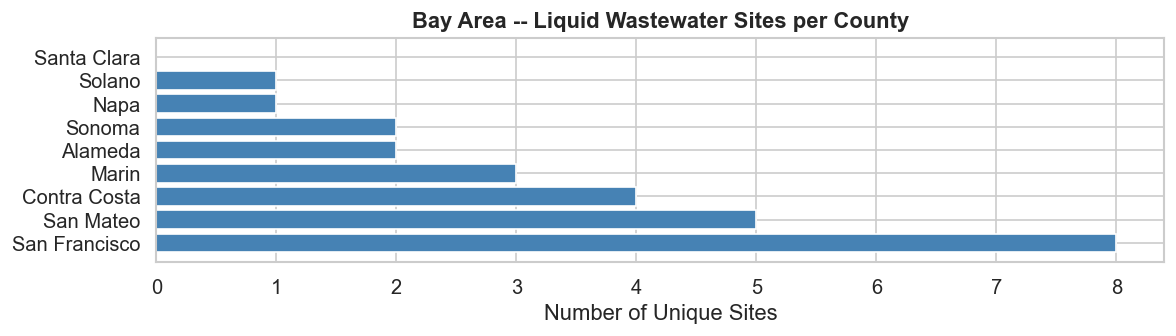

In [173]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.barh(county_site_df['county'], county_site_df['sites'],
        color='steelblue', edgecolor='white')
ax.set_xlabel('Number of Unique Sites')
ax.set_title('Bay Area -- Liquid Wastewater Sites per County', fontweight='bold')
plt.tight_layout()
plt.show()

### 2.2  Statistical summary -- Bay Area

In [174]:
ww_bay[num_summary_cols].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
pcr_target_avg_conc,8004.0,361435.744,731365.306,0.000,32048.676,129545.100,384890.948,2.453768e+07
lod_sewage,8004.0,2026.449,3125.177,1000.000,1000.000,1000.000,1500.000,1.460000e+04
rec_eff_percent,8004.0,71.141,23.989,0.287,57.100,68.741,82.100,2.897590e+02
flow_rate,4995.0,23.507,24.987,0.952,4.300,13.600,36.700,2.474000e+02
population_served,8004.0,199803.741,257028.917,3882.000,9923.000,60000.000,250000.000,7.500000e+05


### 2.3  Missing values -- Bay Area

In [175]:
missing_bay = (
    ww_bay.isnull().sum()
          .to_frame('missing_count')
          .assign(pct=lambda d: (d['missing_count'] / len(ww_bay) * 100).round(1))
          .sort_values('pct', ascending=False)
)
display(missing_bay[missing_bay['pct'] > 1])

,missing_count,pct
inhibition_adjust,5646,70.5
pcr_target_flowpop_lin,3009,37.6
flow_rate,3009,37.6


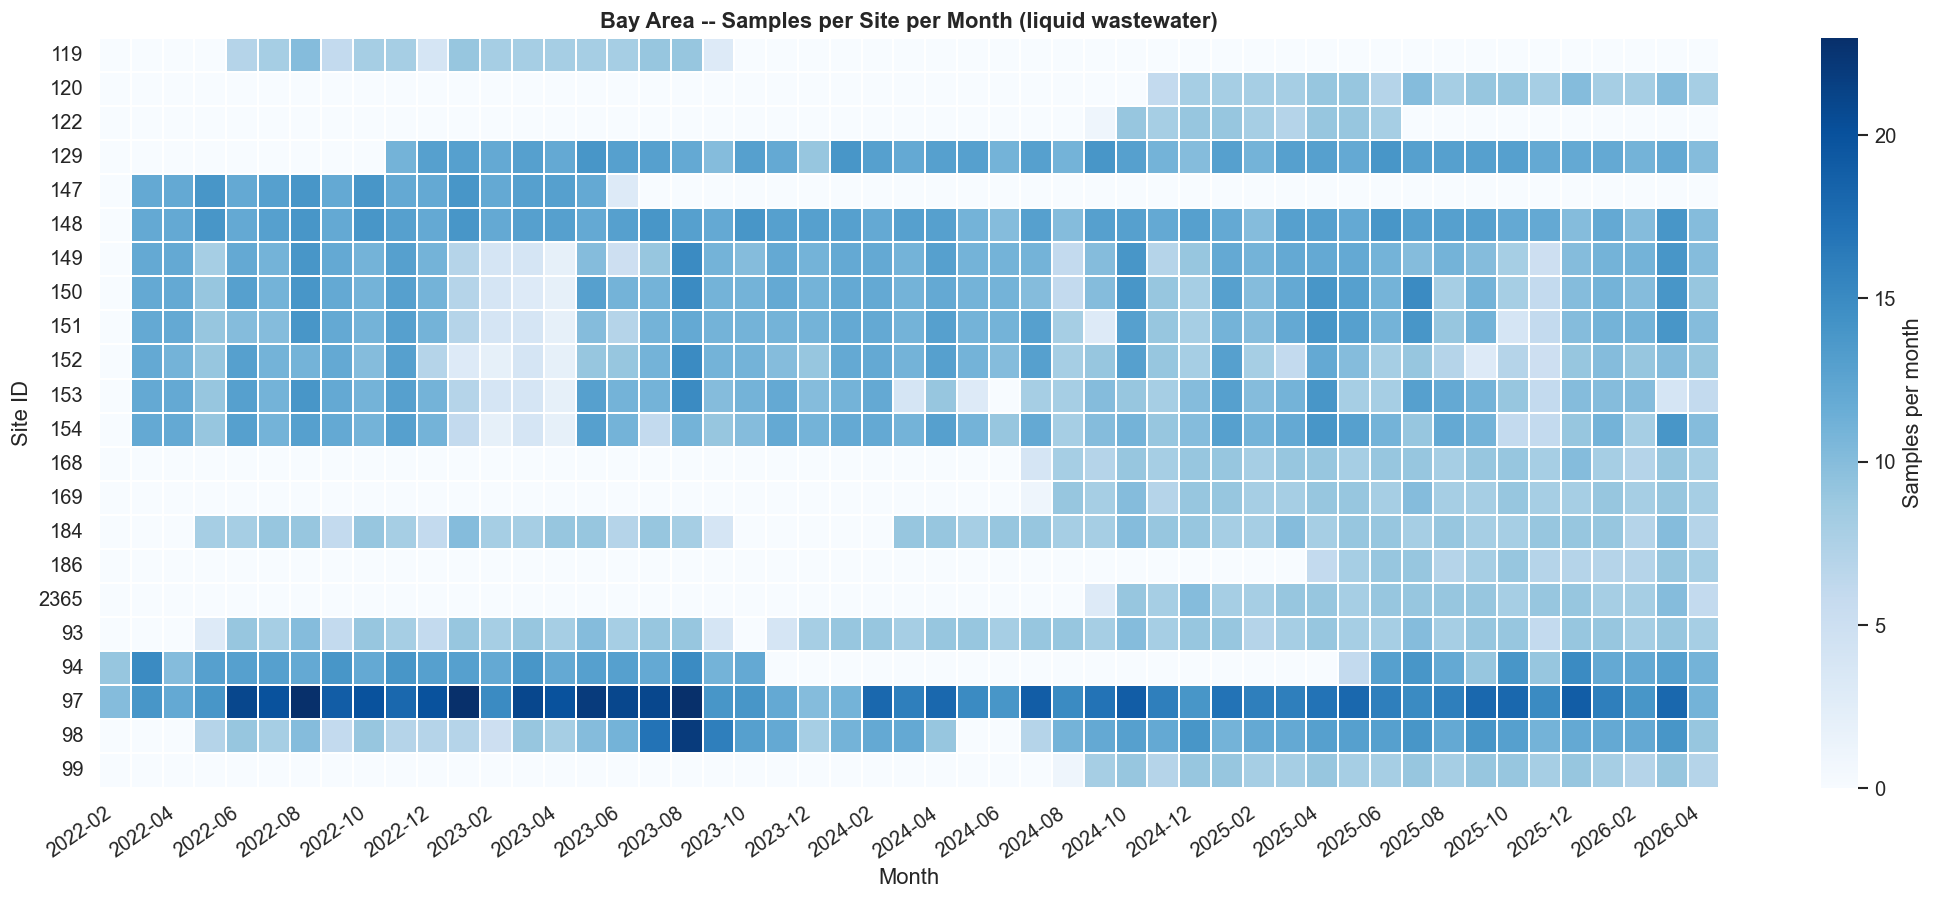

In [176]:
# Temporal coverage heatmap -- one row per site, one column per month.
# White cells mean no data and will require gap-filling or coverage flags
# in the data engineering stage.
ww_bay['month'] = ww_bay['sample_collect_date'].dt.to_period('M')
coverage_pivot = (
    ww_bay.groupby(['site', 'month'])['record_id']
    .count()
    .unstack('month')
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(18, max(4, len(coverage_pivot) * 0.35)))
sns.heatmap(coverage_pivot, cmap='Blues', linewidths=0.2, linecolor='white',
            cbar_kws={'label': 'Samples per month'}, ax=ax, yticklabels=True)
ax.set_title('Bay Area -- Samples per Site per Month (liquid wastewater)', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Site ID')
n_ticks = len(ax.get_xticklabels())
show_every = max(1, n_ticks // 18)
for i, label in enumerate(ax.get_xticklabels()):
    if i % show_every != 0:
        label.set_visible(False)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

### 2.4  Time-series per county -- Bay Area

We aggregate detected samples to a weekly median **per county**.
Where a site spans multiple counties we assign it to all its counties
for this exploratory pass (not population-weighted, just for visualisation).

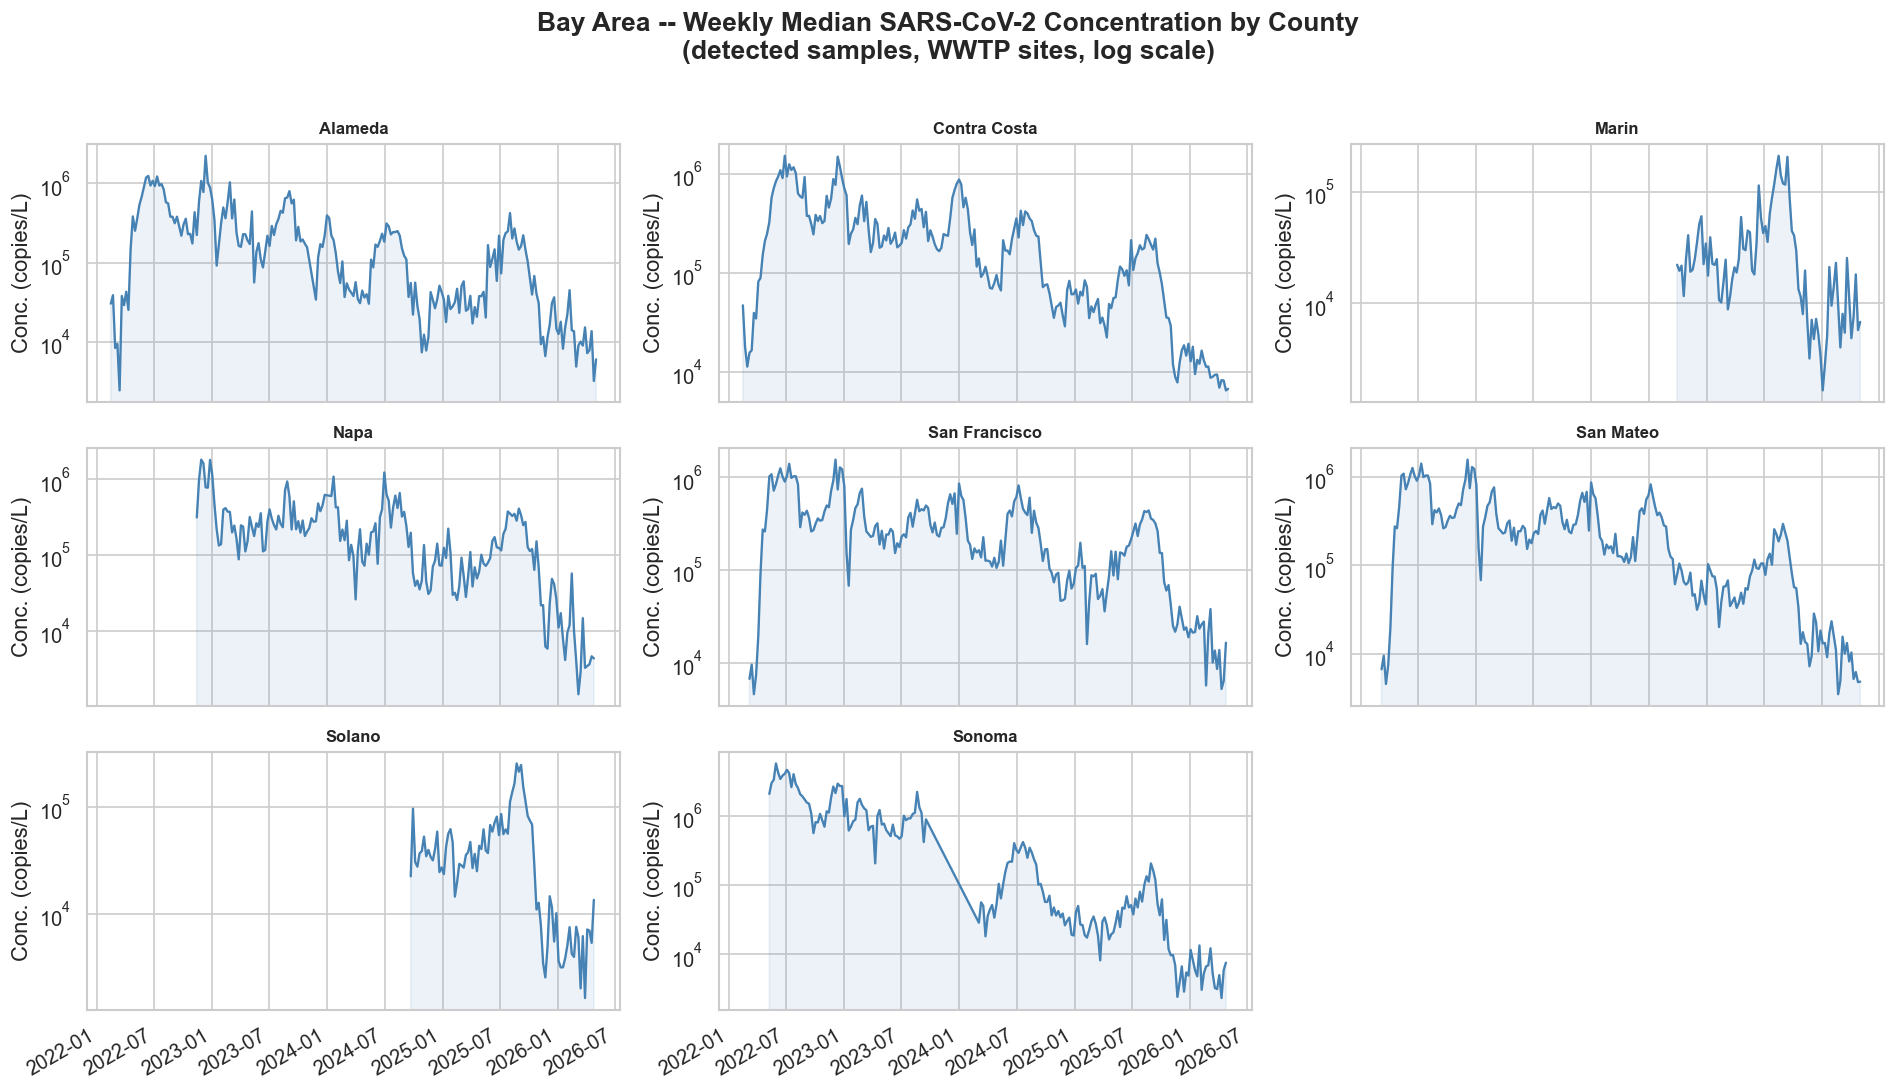

In [177]:
# Explode multi-county sites so each FIPS gets its own row, then filter to Bay Area.
ww_bay_exp = ww_bay.copy()
ww_bay_exp['county_fips_list'] = ww_bay_exp['county_fips'].str.split(',')
ww_bay_exp = ww_bay_exp.explode('county_fips_list')
ww_bay_exp['county_fips_list'] = ww_bay_exp['county_fips_list'].str.strip()
ww_bay_exp = ww_bay_exp[ww_bay_exp['county_fips_list'].isin(BAY_FIPS_PADDED)].copy()
ww_bay_exp['county_name'] = ww_bay_exp['county_fips_list'].map(FIPS_TO_NAME)

ww_bay_wwtp = ww_bay_exp[
    (ww_bay_exp['sample_location'] == 'wwtp') &
    (ww_bay_exp['pcr_target_detect'] == 'yes')
]

weekly_county = (
    ww_bay_wwtp
    .groupby(['county_name', pd.Grouper(key='sample_collect_date', freq='W')])
    ['pcr_target_avg_conc']
    .median()
    .reset_index()
)

counties = sorted(weekly_county['county_name'].dropna().unique())
ncols    = 3
nrows    = -(-len(counties) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3), sharex=True)
axes_flat = axes.flatten()

for ax, county in zip(axes_flat, counties):
    sub = weekly_county[weekly_county['county_name'] == county].sort_values('sample_collect_date')
    ax.semilogy(sub['sample_collect_date'], sub['pcr_target_avg_conc'],
                lw=1.4, color='steelblue')
    ax.fill_between(sub['sample_collect_date'],
                    sub['pcr_target_avg_conc'], alpha=0.1, color='steelblue')
    ax.set_title(county, fontsize=10, fontweight='bold')
    ax.set_ylabel('Conc. (copies/L)')

for ax in axes_flat[len(counties):]:
    ax.set_visible(False)

fig.suptitle('Bay Area -- Weekly Median SARS-CoV-2 Concentration by County\n'
             '(detected samples, WWTP sites, log scale)', fontweight='bold', y=1.01)
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

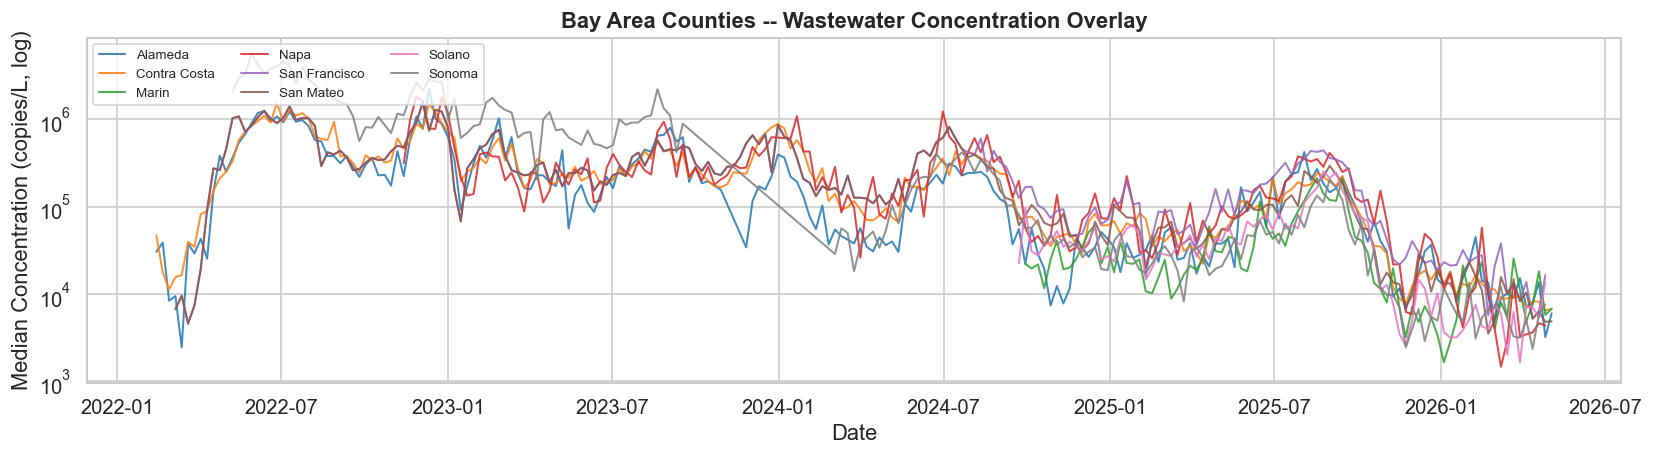

In [178]:
# Overlay all counties -- synchronous peaks across counties indicate epidemic waves;
# county-isolated spikes are candidates for WWTP artifacts.
fig, ax = plt.subplots(figsize=(14, 4))
palette = sns.color_palette('tab10', n_colors=len(counties))
for county, color in zip(counties, palette):
    sub = weekly_county[weekly_county['county_name'] == county].sort_values('sample_collect_date')
    ax.semilogy(sub['sample_collect_date'], sub['pcr_target_avg_conc'],
                lw=1.2, alpha=0.85, label=county, color=color)

ax.set_ylabel('Median Concentration (copies/L, log)')
ax.set_xlabel('Date')
ax.set_title('Bay Area Counties -- Wastewater Concentration Overlay', fontweight='bold')
ax.legend(ncol=3, fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

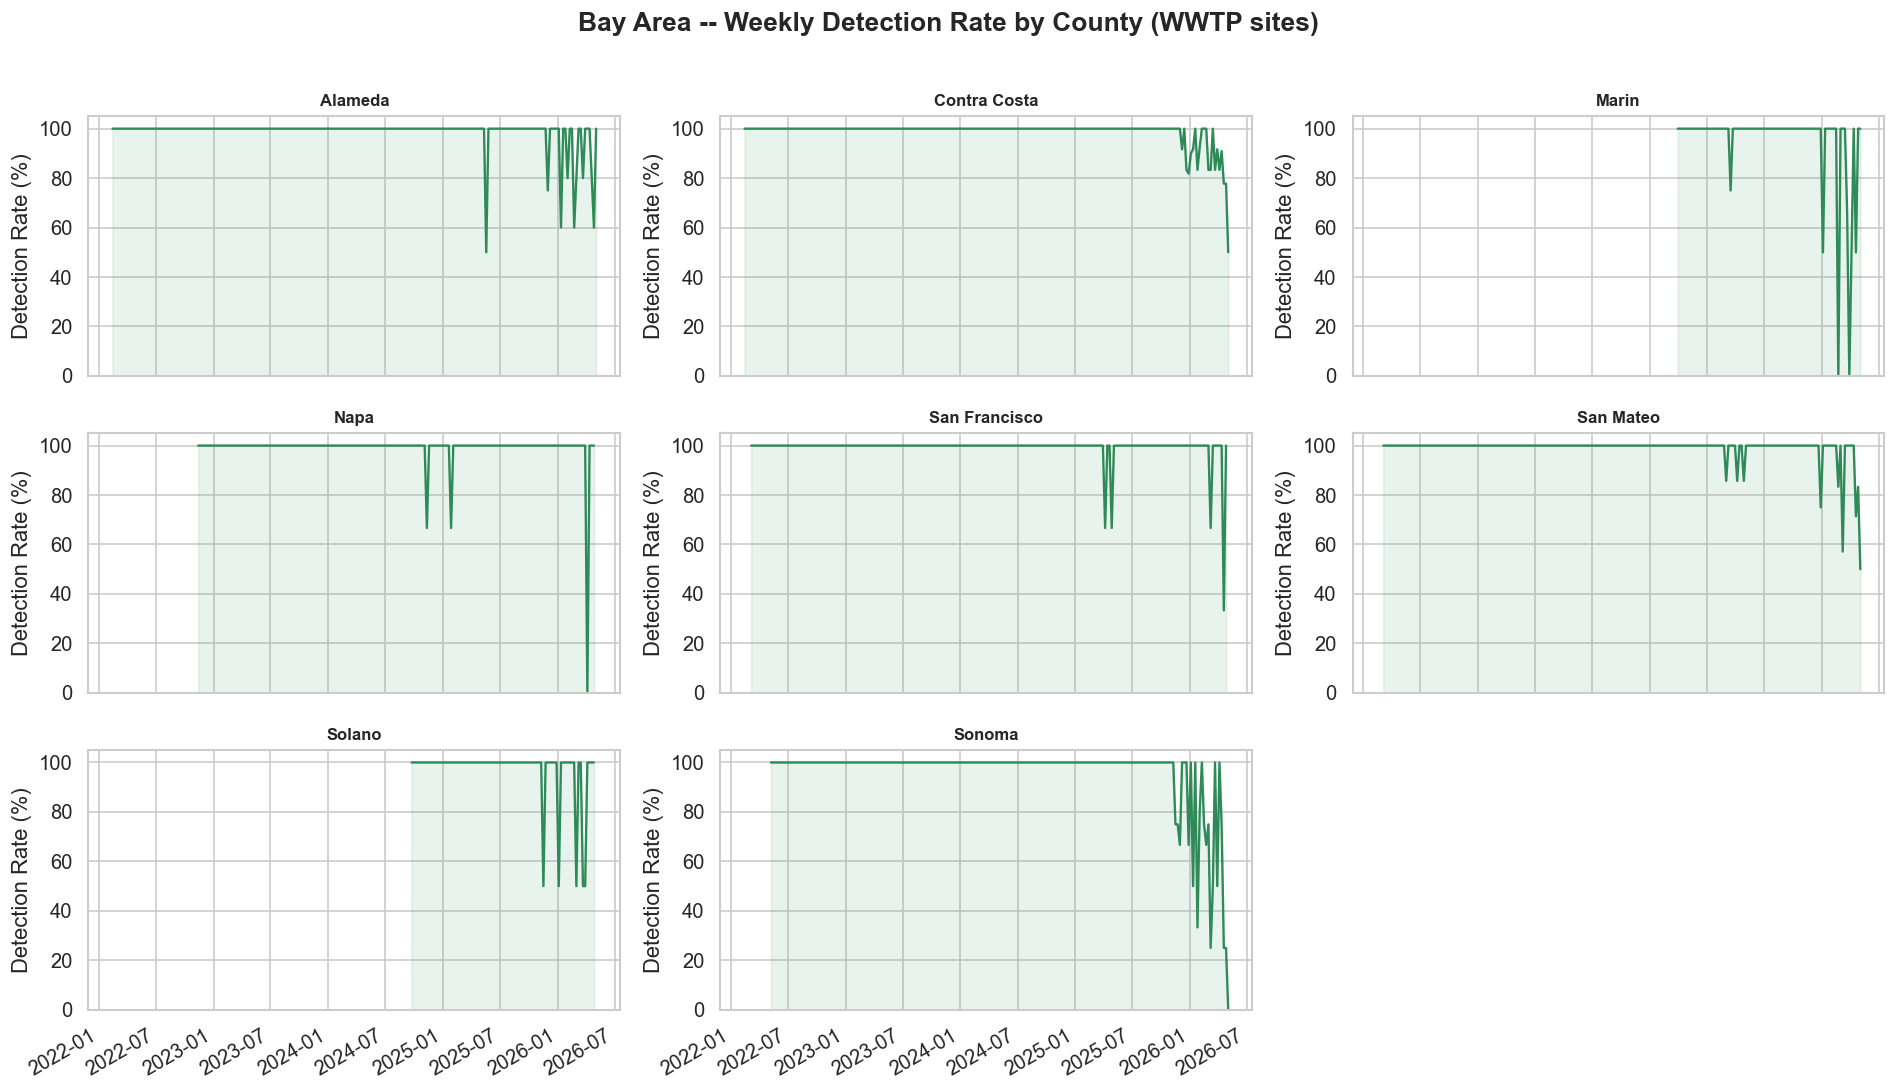

In [179]:
# Detection rate per county over time -- a complementary view to concentration.
# When concentration is near the LOD, detection rate tells us whether the signal
# is reliable or just noise around the detection threshold.
detect_county = (
    ww_bay_exp[ww_bay_exp['sample_location'] == 'wwtp']
    .groupby(['county_name', pd.Grouper(key='sample_collect_date', freq='W')])
    .apply(lambda g: pd.Series({'pct_detected': (g['pcr_target_detect'] == 'yes').mean() * 100}))
    .reset_index()
)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3), sharex=True)
axes_flat = axes.flatten()

for ax, county in zip(axes_flat, counties):
    sub = detect_county[detect_county['county_name'] == county].sort_values('sample_collect_date')
    ax.plot(sub['sample_collect_date'], sub['pct_detected'], lw=1.4, color='seagreen')
    ax.fill_between(sub['sample_collect_date'], sub['pct_detected'], alpha=0.1, color='seagreen')
    ax.set_ylim(0, 105)
    ax.set_title(county, fontsize=10, fontweight='bold')
    ax.set_ylabel('Detection Rate (%)')

for ax in axes_flat[len(counties):]:
    ax.set_visible(False)

fig.suptitle('Bay Area -- Weekly Detection Rate by County (WWTP sites)', fontweight='bold', y=1.01)
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

---
## 3  Dataset 2 -- CDC Weekly COVID Cases & Deaths

This archived county-level dataset provides the **clinical ground truth** we will
use to label outbreak events and evaluate wastewater lead-time.
Each row is one **county x week** with cumulative and new case/death counts.

### 3.1  Load & California filter

In [180]:
cases_raw = pd.read_csv(
    CASES_FILE,
    dtype={'fips_code': str, 'state_fips': str},
)

# Normalise column names (the raw CSV uses mixed case and spaces)
cases_raw.columns = (
    cases_raw.columns.str.strip()
                     .str.lower()
                     .str.replace(' ', '_')
)

print(f'Full dataset shape : {cases_raw.shape}')
print(f'Columns            : {list(cases_raw.columns)}')

Full dataset shape : (566056, 9)
Columns            : ['fips_code', 'county', 'state', 'state_fips', 'date', 'cumulative_cases', 'cumulative_deaths', 'new_cases', 'new_deaths']


In [181]:
cases_ca = cases_raw[cases_raw['state'] == 'CA'].copy()
cases_ca['fips_code'] = cases_ca['fips_code'].str.zfill(5)
cases_ca['date'] = pd.to_datetime(cases_ca['date'], format='%m/%d/%Y')

# The raw CSV stores new_cases and new_deaths as comma-formatted strings
# (e.g. "18,093") — the same issue as the wastewater pcr_target_avg_conc column.
# pd.to_numeric without comma-stripping silently converts any value ≥ 1,000
# to NaN.  Strip commas first, exactly as done for WW data in Section 1.1.
for col in ['cumulative_cases', 'cumulative_deaths', 'new_cases', 'new_deaths']:
    if col in cases_ca.columns:
        cases_ca[col] = pd.to_numeric(
            cases_ca[col].str.replace(',', '', regex=False), errors='coerce')

print(f'California rows    : {len(cases_ca):,}  ({len(cases_ca)/len(cases_raw)*100:.1f}% of national)')
print(f'Unique counties    : {cases_ca["fips_code"].nunique()}')
print(f'Date range         : {cases_ca["date"].min().date()} -> {cases_ca["date"].max().date()}')
neg_rows = (cases_ca['new_cases'] < 0).sum() if 'new_cases' in cases_ca.columns else 0
print(f'Negative new_cases : {neg_rows:,} rows (prior-week revisions — clipped to 0 in charts)')


California rows    : 10,207  (1.8% of national)
Unique counties    : 59
Date range         : 2020-01-22 -> 2023-05-10
Negative new_cases : 58 rows (prior-week revisions — clipped to 0 in charts)


### 3.2  Data types & basic info

In [182]:
cases_ca.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10207 entries, 7612 to 430077
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fips_code          10207 non-null  object        
 1   county             10207 non-null  object        
 2   state              10207 non-null  object        
 3   state_fips         10207 non-null  object        
 4   date               10207 non-null  datetime64[ns]
 5   cumulative_cases   10207 non-null  int64         
 6   cumulative_deaths  10207 non-null  int64         
 7   new_cases          10207 non-null  int64         
 8   new_deaths         4844 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 797.4+ KB


### 3.3  Statistical summary

In [183]:
case_cols = [c for c in ['new_cases', 'new_deaths', 'cumulative_cases', 'cumulative_deaths']
             if c in cases_ca.columns]
cases_ca[case_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
new_cases,10207.0,1200.34,6437.78,-13568.0,19.0,146.0,646.0,276668.0
new_deaths,4844.0,14.81,70.04,0.0,0.0,1.0,7.0,1582.0
cumulative_cases,10207.0,97187.57,316385.96,0.0,1424.5,12339.0,64718.0,3742471.0
cumulative_deaths,10207.0,1001.52,3433.64,0.0,10.0,127.0,590.5,36049.0


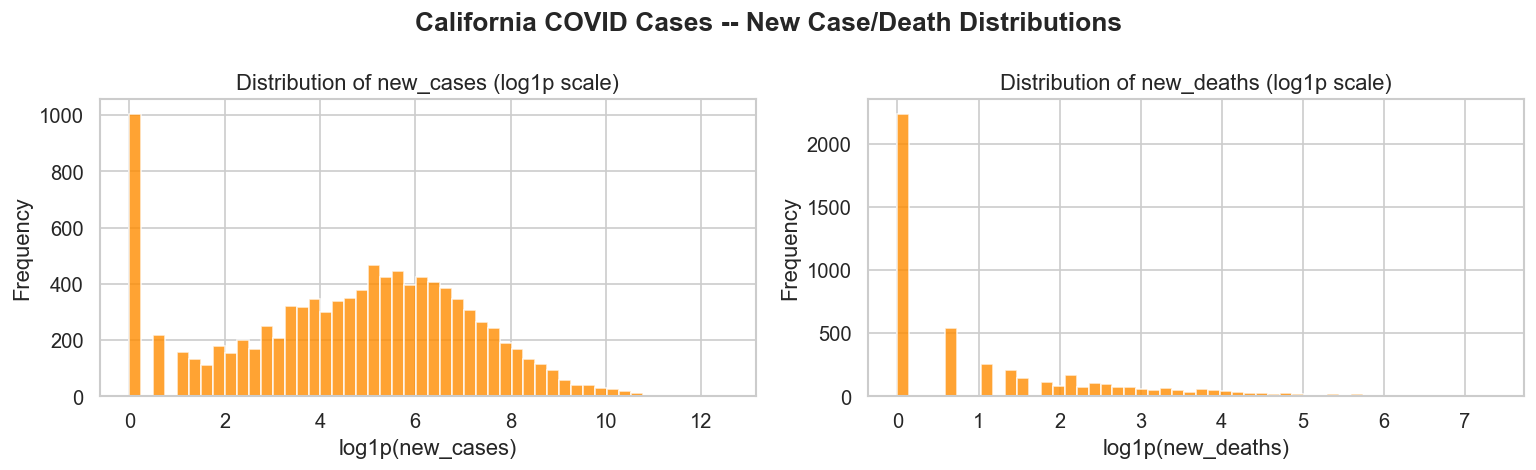

In [184]:
# Log1p histogram -- most counties in most weeks report low counts;
# a few large counties (LA, SF, Santa Clara) dominate the linear scale.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ['new_cases', 'new_deaths']):
    if col in cases_ca.columns:
        ax.hist(np.log1p(cases_ca[col].clip(lower=0).dropna()),
                bins=50, color='darkorange', edgecolor='white', alpha=0.8)
        ax.set_xlabel(f'log1p({col})')
        ax.set_ylabel('Frequency')
        ax.set_title(f'Distribution of {col} (log1p scale)')

fig.suptitle('California COVID Cases -- New Case/Death Distributions', fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4  Missing value analysis

In [185]:
missing_cases = (
    cases_ca.isnull().sum()
            .to_frame('missing_count')
            .assign(pct=lambda d: (d['missing_count'] / len(cases_ca) * 100).round(2))
            .sort_values('missing_count', ascending=False)
)
display(missing_cases[missing_cases['missing_count'] > 0])

,missing_count,pct
new_deaths,5363,52.54


In [186]:
# Negative new_cases arise when a prior week's reported total is revised downward.
# They are not actual reductions in infections and should be clipped to zero
# before any analysis or modelling that uses new_cases as a label.
neg_cases = cases_ca[cases_ca.get('new_cases', pd.Series(dtype=float)) < 0]
print(f'Rows with negative new_cases: {len(neg_cases):,} '
      f'({len(neg_cases)/len(cases_ca)*100:.2f}%)')
if len(neg_cases):
    display(neg_cases[['fips_code', 'county', 'date', 'new_cases', 'cumulative_cases']].head(10))

Rows with negative new_cases: 58 (0.57%)


,fips_code,county,date,new_cases,cumulative_cases
288749,06000,Unallocated California,2020-04-15,-167,0
288802,06000,Unallocated California,2021-04-21,-19,47
288804,06000,Unallocated California,2021-05-05,-9,44
288805,06000,Unallocated California,2021-05-12,-7,37
288806,06000,Unallocated California,2021-05-19,-8,29
288810,06000,Unallocated California,2021-06-16,-5,33
288814,06000,Unallocated California,2021-07-14,-11,26
288815,06000,Unallocated California,2021-07-21,-1,25
288818,06000,Unallocated California,2021-08-11,-1,80
288819,06000,Unallocated California,2021-08-18,-7,73


### 3.5  Time-series exploration -- California

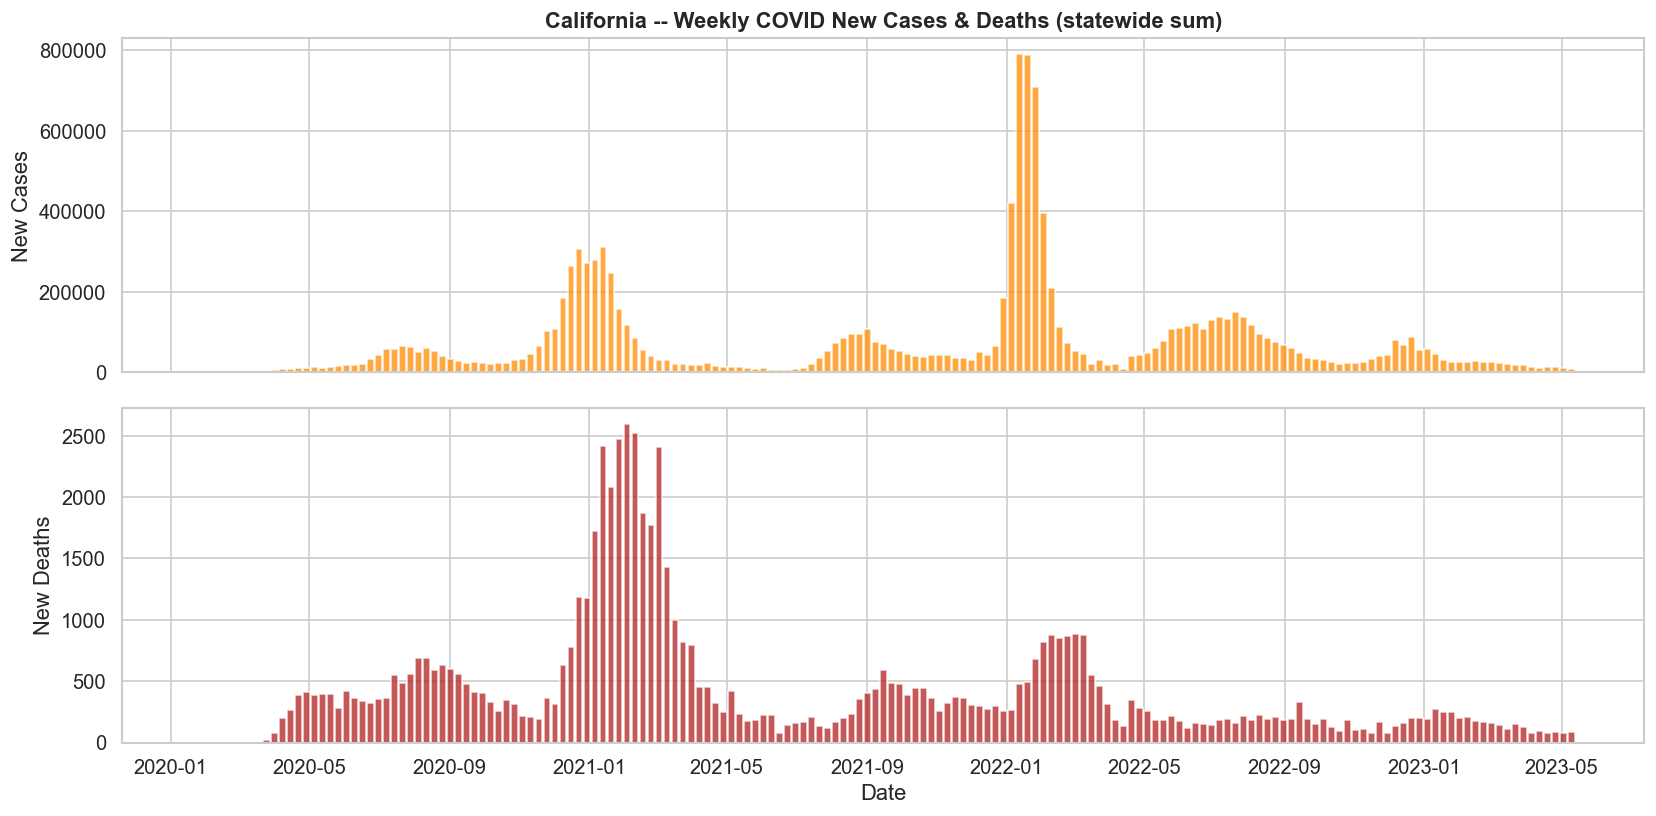

In [187]:
ca_weekly_cases = (
    cases_ca.groupby('date')[['new_cases', 'new_deaths']]
    .sum()
    .reset_index()
    .sort_values('date')
)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, (col, color) in zip(axes, [('new_cases', 'darkorange'), ('new_deaths', 'firebrick')]):
    if col in ca_weekly_cases.columns:
        ax.bar(ca_weekly_cases['date'], ca_weekly_cases[col].clip(lower=0),
               width=6, color=color, alpha=0.75)
        ax.set_ylabel(col.replace('_', ' ').title())

axes[0].set_title('California -- Weekly COVID New Cases & Deaths (statewide sum)', fontweight='bold')
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

---
## 4  Dataset 2 -- Bay Area Subset

### 4.1  Subset & sanity checks

In [188]:
cases_bay = cases_ca[cases_ca['fips_code'].isin(BAY_FIPS_PADDED)].copy()
cases_bay = cases_bay.assign(county_name=lambda d: d['fips_code'].map(FIPS_TO_NAME))
# new_cases is now fully numeric (comma fix applied in 3.1).
# new_cases_reported is always True; kept for API compatibility with downstream cells.
cases_bay['new_cases_reported'] = cases_bay['new_cases'].notna()

print(f'Bay Area rows    : {len(cases_bay):,}  ({len(cases_bay)/len(cases_ca)*100:.1f}% of CA)')
print(f'Unique counties  : {cases_bay["fips_code"].nunique()} / 9 expected')
print(f'Date range       : {cases_bay["date"].min().date()} -> {cases_bay["date"].max().date()}')

# ── Overlap window ────────────────────────────────────────────────────────────
# WW data starts 2022-02-07 (first Bay Area WWTP detected sample).
# Cases archive ends 2023-05-10.  All Section 4 analysis is scoped to this window.
OVERLAP_START = max(ww_bay['sample_collect_date'].min(), cases_bay['date'].min())
OVERLAP_END   = min(ww_bay['sample_collect_date'].max(), cases_bay['date'].max())
print(f'\nOverlap window   : {OVERLAP_START.date()} -> {OVERLAP_END.date()}')
print(f'Overlap duration : {(OVERLAP_END - OVERLAP_START).days // 7} weeks')

cases_bay_ov = cases_bay[
    (cases_bay['date'] >= OVERLAP_START) & (cases_bay['date'] <= OVERLAP_END)
].copy()
print(f'\ncases_bay_ov     : {len(cases_bay_ov):,} rows  ({cases_bay_ov["fips_code"].nunique()} counties × '
      f'{cases_bay_ov["date"].nunique()} weeks)')

# ── Spine regularity ──────────────────────────────────────────────────────────
dow = int(cases_bay['date'].dt.dayofweek.mode()[0])
dow_names = {0:'Monday',1:'Tuesday',2:'Wednesday',3:'Thursday',4:'Friday',5:'Saturday',6:'Sunday'}
gaps = cases_bay.groupby('fips_code')['date'].apply(lambda s: s.sort_values().diff().dt.days.dropna())
print(f'Date anchor      : {dow_names[dow]} (dayofweek={dow})')
print(f'Date spacing     : min={int(gaps.min())}d  max={int(gaps.max())}d  (all 7d = {gaps.min()==gaps.max()==7})')

miss_ov = (
    cases_bay_ov.groupby('county_name')['new_cases']
    .apply(lambda s: pd.Series({'n_weeks': len(s), 'reported': int(s.notna().sum()),
                                'pct_null': round(s.isna().mean()*100, 1)}))
    .unstack()
    .sort_values('pct_null', ascending=False)
)
print('\n── new_cases completeness in overlap window (2022-02-07 → 2023-05-10) ──')
display(miss_ov)


Bay Area rows    : 1,557  (15.3% of CA)
Unique counties  : 9 / 9 expected
Date range       : 2020-01-22 -> 2023-05-10

Overlap window   : 2022-02-07 -> 2023-05-10
Overlap duration : 65 weeks

cases_bay_ov     : 594 rows  (9 counties × 66 weeks)
Date anchor      : Wednesday (dayofweek=2)
Date spacing     : min=7d  max=7d  (all 7d = True)

── new_cases completeness in overlap window (2022-02-07 → 2023-05-10) ──


,n_weeks,reported,pct_null
county_name,,,
Alameda,66.0,66.0,0.0
Contra Costa,66.0,66.0,0.0
Marin,66.0,66.0,0.0
Napa,66.0,66.0,0.0
San Francisco,66.0,66.0,0.0
San Mateo,66.0,66.0,0.0
Santa Clara,66.0,66.0,0.0
Solano,66.0,66.0,0.0
Sonoma,66.0,66.0,0.0


### 4.2  Statistical summary -- Bay Area

In [189]:
cases_bay[case_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
new_cases,1557.0,1260.15,2730.91,0.0,183.0,500.0,1219.0,34767.0
new_deaths,692.0,5.45,10.69,0.0,0.0,2.0,6.0,109.0
cumulative_cases,1557.0,92531.05,114638.04,0.0,11172.0,42968.0,121753.0,504864.0
cumulative_deaths,1557.0,622.60,678.21,0.0,130.0,358.0,843.0,2787.0


### 4.3  Missing & negative values -- Bay Area

In [190]:
# All analysis in Section 4 is scoped to the overlap window (2022-02-07 → 2023-05-10).
# After stripping comma-formatted numbers (fix in Section 3.1), new_cases is complete:
# 0% null across all counties and all weeks in the overlap window.

# ── Negative new_cases (reporting revisions) ──────────────────────────────────
# Negative values arise when a prior week's cumulative total is revised downward.
# They are real data quality issues, not the same as "missing", but must be clipped
# to 0 before modelling.
neg_summary = (
    cases_bay_ov.groupby('county_name')['new_cases']
    .apply(lambda s: pd.Series({'n_weeks': len(s),
                                'n_negative': int((s < 0).sum()),
                                'min_value' : round(float(s.min()), 0),
                                'max_value' : round(float(s.max()), 0)}))
    .unstack()
    .sort_values('n_negative', ascending=False)
)
print('── new_cases negative revisions per county (overlap window) ──')
display(neg_summary)


── new_cases negative revisions per county (overlap window) ──


,n_weeks,n_negative,min_value,max_value
county_name,,,,
Alameda,66.0,0.0,494.0,6809.0
Contra Costa,66.0,0.0,264.0,4701.0
Marin,66.0,0.0,0.0,1189.0
Napa,66.0,0.0,17.0,1551.0
San Francisco,66.0,0.0,0.0,3986.0
San Mateo,66.0,0.0,213.0,3481.0
Santa Clara,66.0,0.0,527.0,9570.0
Solano,66.0,0.0,14.0,4538.0
Sonoma,66.0,0.0,93.0,2420.0


### 4.4  Time-series per county — Bay Area (overlap window: 2022-02-07 → 2023-05-10)

**Data quality note**: All `new_cases` values are now correctly parsed (comma-formatted
strings stripped before numeric conversion).  Missingness is **0 %** across all counties
within the overlap window.  Negative values (prior-week revisions) are clipped to 0 in
charts but tracked separately above.

Santa Clara uses `copies/g dry sludge` for wastewater — shown separately in 4.4b.

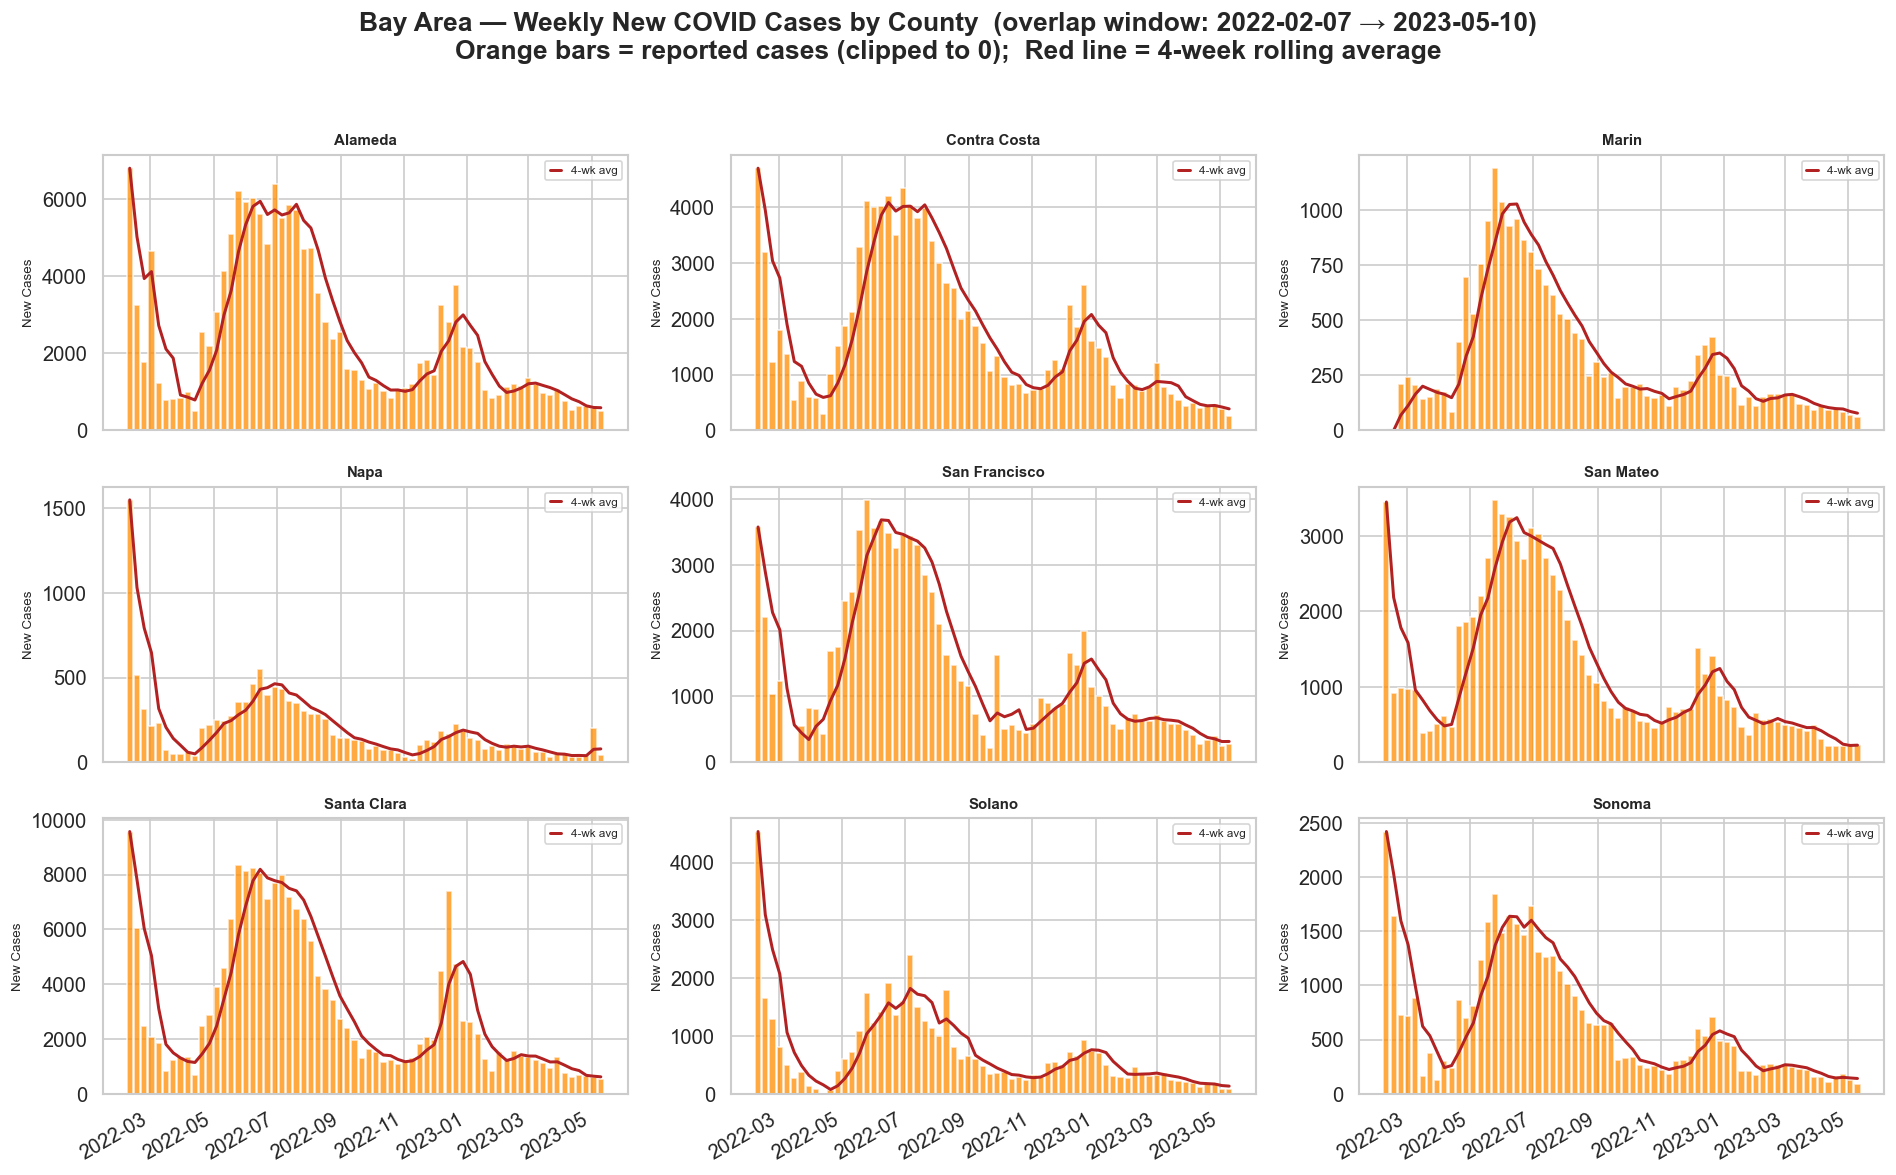

In [191]:
counties_cases = sorted(cases_bay_ov['county_name'].dropna().unique())
ncols   = 3
nrows_c = -(-len(counties_cases) // ncols)

fig, axes = plt.subplots(nrows_c, ncols, figsize=(16, nrows_c * 3.2), sharex=True)
axes_flat_c = axes.flatten()

for ax, county in zip(axes_flat_c, counties_cases):
    sub  = cases_bay_ov[cases_bay_ov['county_name'] == county].sort_values('date')
    vals = sub['new_cases'].clip(lower=0)

    ax.bar(sub['date'], vals, width=6, color='darkorange', alpha=0.75)

    # 4-week rolling average to reveal trend through reporting noise
    roll = vals.rolling(4, min_periods=1).mean()
    ax.plot(sub['date'], roll, color='firebrick', lw=1.8, label='4-wk avg')

    n_neg = int((sub['new_cases'] < 0).sum())
    title = county + (f'  ({n_neg} revision wks clipped)' if n_neg else '')
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_ylabel('New Cases', fontsize=8)
    ax.legend(fontsize=7, loc='upper right', handlelength=1)

for ax in axes_flat_c[len(counties_cases):]:
    ax.set_visible(False)

fig.suptitle(
    'Bay Area — Weekly New COVID Cases by County  (overlap window: 2022-02-07 → 2023-05-10)\n'
    'Orange bars = reported cases (clipped to 0);  Red line = 4-week rolling average',
    fontweight='bold', y=1.02,
)
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()


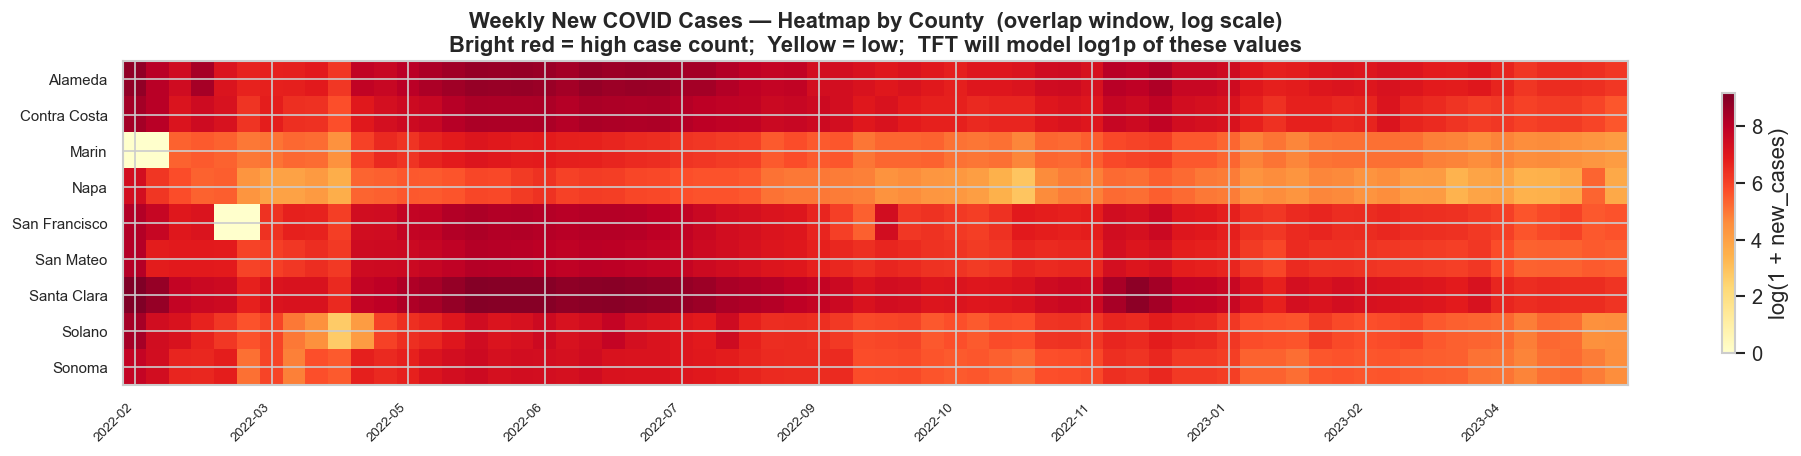

In [192]:
import matplotlib.colors as mcolors

# Weekly case counts heatmap (county × week, log scale).
# This is more informative than a data-availability heatmap since
# all weeks are now fully reported.
pivot_cases = cases_bay_ov.pivot_table(
    index='county_name', columns='date',
    values='new_cases', aggfunc='first',
).clip(lower=0)   # clip revisions to 0

fig, ax = plt.subplots(figsize=(17, 4))
log_pivot = np.log1p(pivot_cases.values.astype(float))
im = ax.imshow(log_pivot, aspect='auto', cmap='YlOrRd', interpolation='none')
plt.colorbar(im, ax=ax, label='log(1 + new_cases)', shrink=0.8)

n_dates = len(pivot_cases.columns)
step = max(1, n_dates // 10)
ax.set_xticks(range(0, n_dates, step))
ax.set_xticklabels(
    [pivot_cases.columns[i].strftime('%Y-%m') for i in range(0, n_dates, step)],
    rotation=45, ha='right', fontsize=8,
)
ax.set_yticks(range(len(pivot_cases)))
ax.set_yticklabels(pivot_cases.index, fontsize=9)
ax.set_title(
    'Weekly New COVID Cases — Heatmap by County  (overlap window, log scale)\n'
    'Bright red = high case count;  Yellow = low;  TFT will model log1p of these values',
    fontweight='bold',
)
plt.tight_layout()
plt.show()


#### 4.4b  Santa Clara County — Wastewater in copies/g dry sludge

Santa Clara is California's third-largest county by population (~2M).  Its
WWTP operators report in `copies/g dry sludge`, a unit used by sludge-based
assays.  Converting to copies/l requires TSS (total suspended solids) data
that is not consistently present in the NWSS dataset, so we treat Santa Clara
as a **separate analysis track**.

Santa Clara — unit distribution:
pcr_target_units
copies/g dry sludge    7928

Date range: 2020-03-18 -> 2026-04-28
WWTP sites: 4


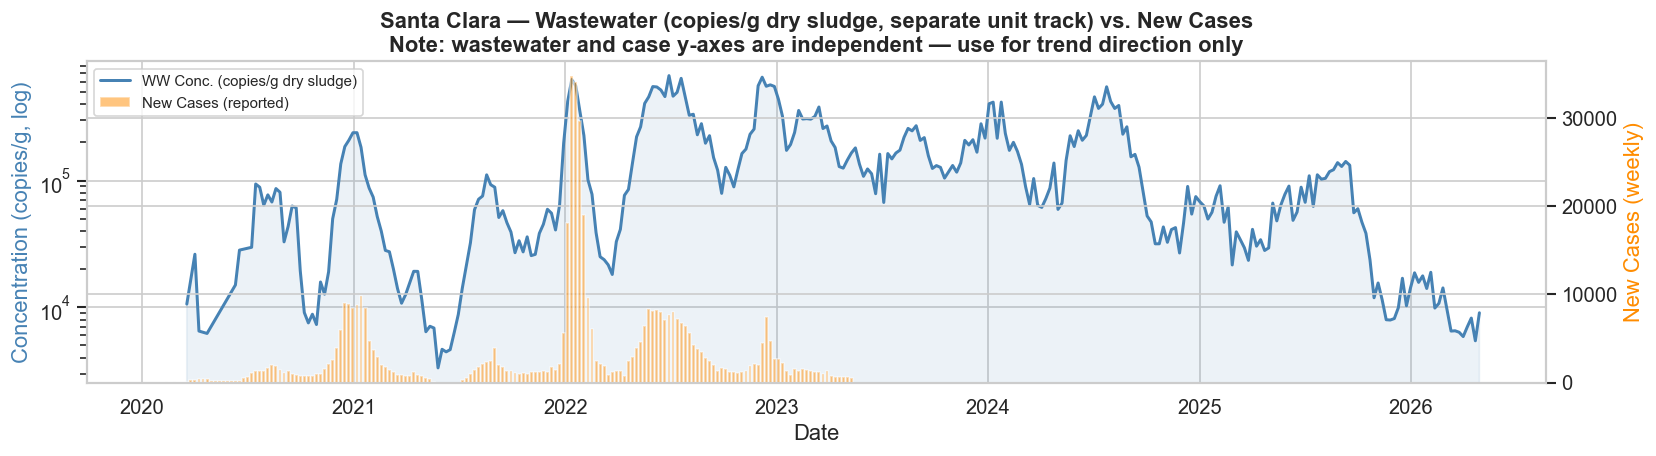


Santa Clara WW weekly samples: 310
Overlap with cases data: 155 weeks


In [193]:
SC_FIPS = '06085'

# Load Santa Clara wastewater — copies/g dry sludge unit
ww_ca_sc = ww_raw[
    (ww_raw['state_territory'] == 'ca') &
    (ww_raw['county_fips'].fillna('').str.contains(r'\b6085\b', regex=True) |
     ww_raw['county_fips'].fillna('').str.contains('06085'))
].copy()
ww_ca_sc['pcr_target_avg_conc'] = pd.to_numeric(
    ww_ca_sc['pcr_target_avg_conc'].astype(str).str.replace(',', ''), errors='coerce')
ww_ca_sc['sample_collect_date'] = pd.to_datetime(ww_ca_sc['sample_collect_date'], errors='coerce')

sc_units = ww_ca_sc['pcr_target_units'].value_counts()
print('Santa Clara — unit distribution:')
print(sc_units.to_string())
print(f'\nDate range: {ww_ca_sc["sample_collect_date"].min().date()} -> '
      f'{ww_ca_sc["sample_collect_date"].max().date()}')
print(f'WWTP sites: {ww_ca_sc[ww_ca_sc["sample_location"]=="wwtp"]["site"].nunique()}')

# Focus on the dominant sludge unit
ww_sc_sludge = ww_ca_sc[
    ww_ca_sc['pcr_target_units'].str.contains('copies/g', na=False, case=False) &
    (ww_ca_sc['sample_location'] == 'wwtp') &
    (ww_ca_sc['pcr_target_detect'] == 'yes')
].copy()

if len(ww_sc_sludge) > 0:
    sc_weekly = (
        ww_sc_sludge
        .set_index('sample_collect_date')['pcr_target_avg_conc']
        .resample('W-WED').median()
        .dropna()
    )
    cases_sc = cases_bay[cases_bay['fips_code'] == SC_FIPS].sort_values('date')

    fig, ax1 = plt.subplots(figsize=(14, 4))
    ax2 = ax1.twinx()

    ax1.semilogy(sc_weekly.index, sc_weekly.values,
                 color='steelblue', lw=1.8, label='WW Conc. (copies/g dry sludge)')
    ax1.fill_between(sc_weekly.index, sc_weekly.values, alpha=0.1, color='steelblue')
    ax1.set_ylabel('Concentration (copies/g, log)', color='steelblue')

    rep_sc = cases_sc[cases_sc['new_cases_reported']]
    mis_sc = cases_sc[~cases_sc['new_cases_reported']]
    max_c  = rep_sc['new_cases'].clip(lower=0).max() if len(rep_sc) else 1.0

    ax2.bar(rep_sc['date'], rep_sc['new_cases'].clip(lower=0),
            width=5, alpha=0.5, color='darkorange', label='New Cases (reported)')
    if len(mis_sc):
        ax2.bar(mis_sc['date'], max_c * 0.02, width=5,
                alpha=0.3, color='gray', label=f'No case report ({len(mis_sc)} wks)')
    ax2.set_ylabel('New Cases (weekly)', color='darkorange')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    ax1.set_xlabel('Date')
    ax1.set_title(
        'Santa Clara — Wastewater (copies/g dry sludge, separate unit track) vs. New Cases\n'
        'Note: wastewater and case y-axes are independent — use for trend direction only',
        fontweight='bold',
    )
    plt.tight_layout()
    plt.show()

    print(f'\nSanta Clara WW weekly samples: {len(sc_weekly)}')
    print(f'Overlap with cases data: {sum((sc_weekly.index >= cases_sc["date"].min()) & (sc_weekly.index <= cases_sc["date"].max()))} weeks')
else:
    print('No Santa Clara sludge-unit WWTP detected samples found.')


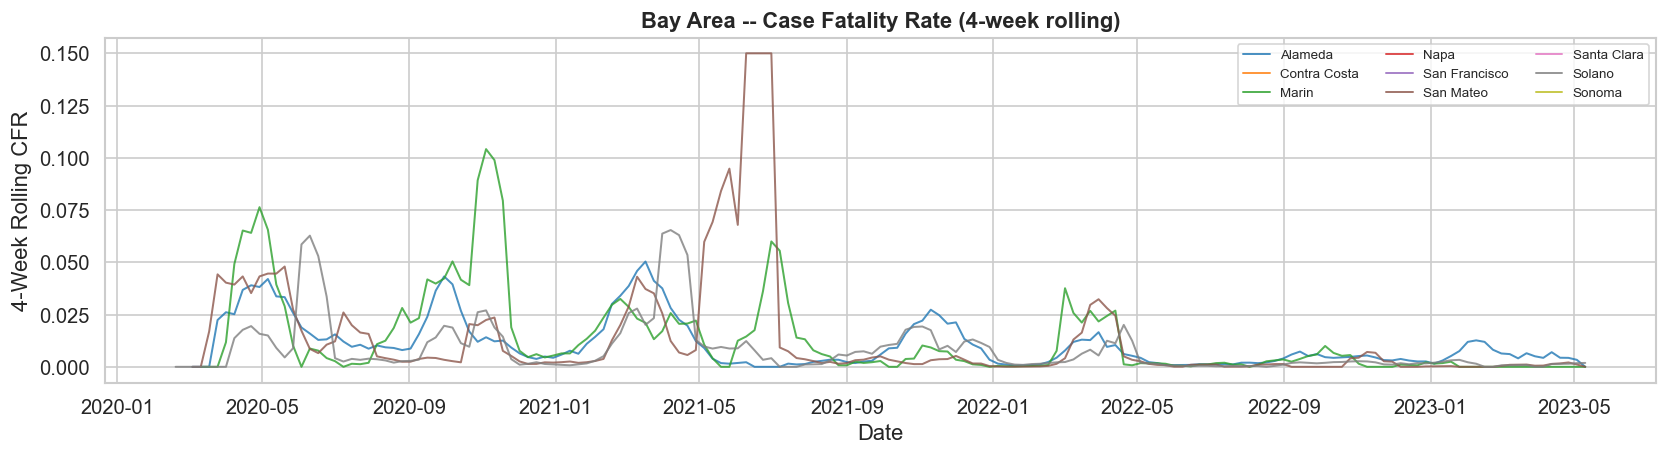

In [194]:
# 4-week rolling case fatality rate -- smoothed to reduce reporting-lag noise.
# A rising CFR can precede hospitalisation surges and is useful context
# for understanding what the wastewater signal is tracking.
cfr_frames = []
for county, grp in cases_bay.groupby('county_name'):
    grp = grp.sort_values('date').copy()
    cases_4w  = grp['new_cases'].clip(lower=0).rolling(4, min_periods=1).sum()
    deaths_4w = grp['new_deaths'].clip(lower=0).rolling(4, min_periods=1).sum()
    grp['cfr_4w'] = deaths_4w / cases_4w.replace(0, np.nan)
    cfr_frames.append(grp)

cfr_df = pd.concat(cfr_frames)

fig, ax = plt.subplots(figsize=(14, 4))
for county, color in zip(counties_cases, sns.color_palette('tab10', len(counties_cases))):
    sub = cfr_df[cfr_df['county_name'] == county]
    ax.plot(sub['date'], sub['cfr_4w'].clip(0, 0.15),
            lw=1.2, alpha=0.8, label=county, color=color)
ax.set_ylabel('4-Week Rolling CFR')
ax.set_xlabel('Date')
ax.set_title('Bay Area -- Case Fatality Rate (4-week rolling)', fontweight='bold')
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

---
## 5  Cross-Dataset Alignment

Before modelling, we confirm that the wastewater and clinical signals share a
common county FIPS spine and overlapping time windows.

### 5.1  Temporal overlap

In [195]:
ww_start,  ww_end   = ww_bay['sample_collect_date'].min(),  ww_bay['sample_collect_date'].max()
cas_start, cas_end  = cases_bay['date'].min(),               cases_bay['date'].max()

overlap_start = max(ww_start, cas_start)
overlap_end   = min(ww_end,   cas_end)

print(f'Wastewater dates : {ww_start.date()} -> {ww_end.date()}')
print(f'Cases dates      : {cas_start.date()} -> {cas_end.date()}')
print(f'Overlap window   : {overlap_start.date()} -> {overlap_end.date()}')
print(f'Overlap duration : {(overlap_end - overlap_start).days} days  '
      f'({(overlap_end - overlap_start).days // 7} weeks)')

# ── Date-anchor mismatch diagnosis ──────────────────────────────────────────
dow_abbr = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
ww_dow   = int(ww_bay['sample_collect_date'].dt.dayofweek.mode()[0])
cas_dow  = int(cases_bay['date'].dt.dayofweek.mode()[0])
offset   = min(abs(cas_dow - ww_dow), 7 - abs(cas_dow - ww_dow))

print(f'\nDate anchor — wastewater : {dow_abbr[ww_dow]} (dayofweek={ww_dow})')
print(f'Date anchor — cases      : {dow_abbr[cas_dow]} (dayofweek={cas_dow})')
print(f'Systematic offset        : {offset} day(s)')
if offset > 0:
    print('  ⚠  Week boundaries differ. We resample wastewater to W-WED (Wednesday)')
    print('     before any cross-dataset merge to eliminate the systematic offset.')


Wastewater dates : 2022-02-07 -> 2026-04-28
Cases dates      : 2020-01-22 -> 2023-05-10
Overlap window   : 2022-02-07 -> 2023-05-10
Overlap duration : 457 days  (65 weeks)

Date anchor — wastewater : Tue (dayofweek=1)
Date anchor — cases      : Wed (dayofweek=2)
Systematic offset        : 1 day(s)
  ⚠  Week boundaries differ. We resample wastewater to W-WED (Wednesday)
     before any cross-dataset merge to eliminate the systematic offset.


### 5.2  County FIPS alignment

In [196]:
ww_fips    = set(ww_bay_exp['county_fips_list'].unique())
cases_fips = set(cases_bay['fips_code'].unique())

in_ww_not_cases = ww_fips - cases_fips
in_cases_not_ww = cases_fips - ww_fips
in_both         = ww_fips & cases_fips

print(f'Counties in both datasets : {len(in_both)}')
print(f'In wastewater only        : {sorted(FIPS_TO_NAME.get(f, f) for f in in_ww_not_cases)}')
print(f'In cases only             : {sorted(FIPS_TO_NAME.get(f, f) for f in in_cases_not_ww)}')

Counties in both datasets : 8
In wastewater only        : []
In cases only             : ['Santa Clara']


### 5.3  Merged signals — four illustrative counties

We plot wastewater concentration alongside weekly new cases for San Francisco,
Contra Costa, San Mateo, and Santa Clara.  Santa Clara uses `copies/g dry sludge`
(its own y-axis scale) while the others use `copies/l wastewater`.

A **left-shift** of the wastewater curve relative to the case bars is the
central hypothesis — wastewater should peak before the clinical case count.
We restrict to the overlap window to avoid misleading extrapolations.

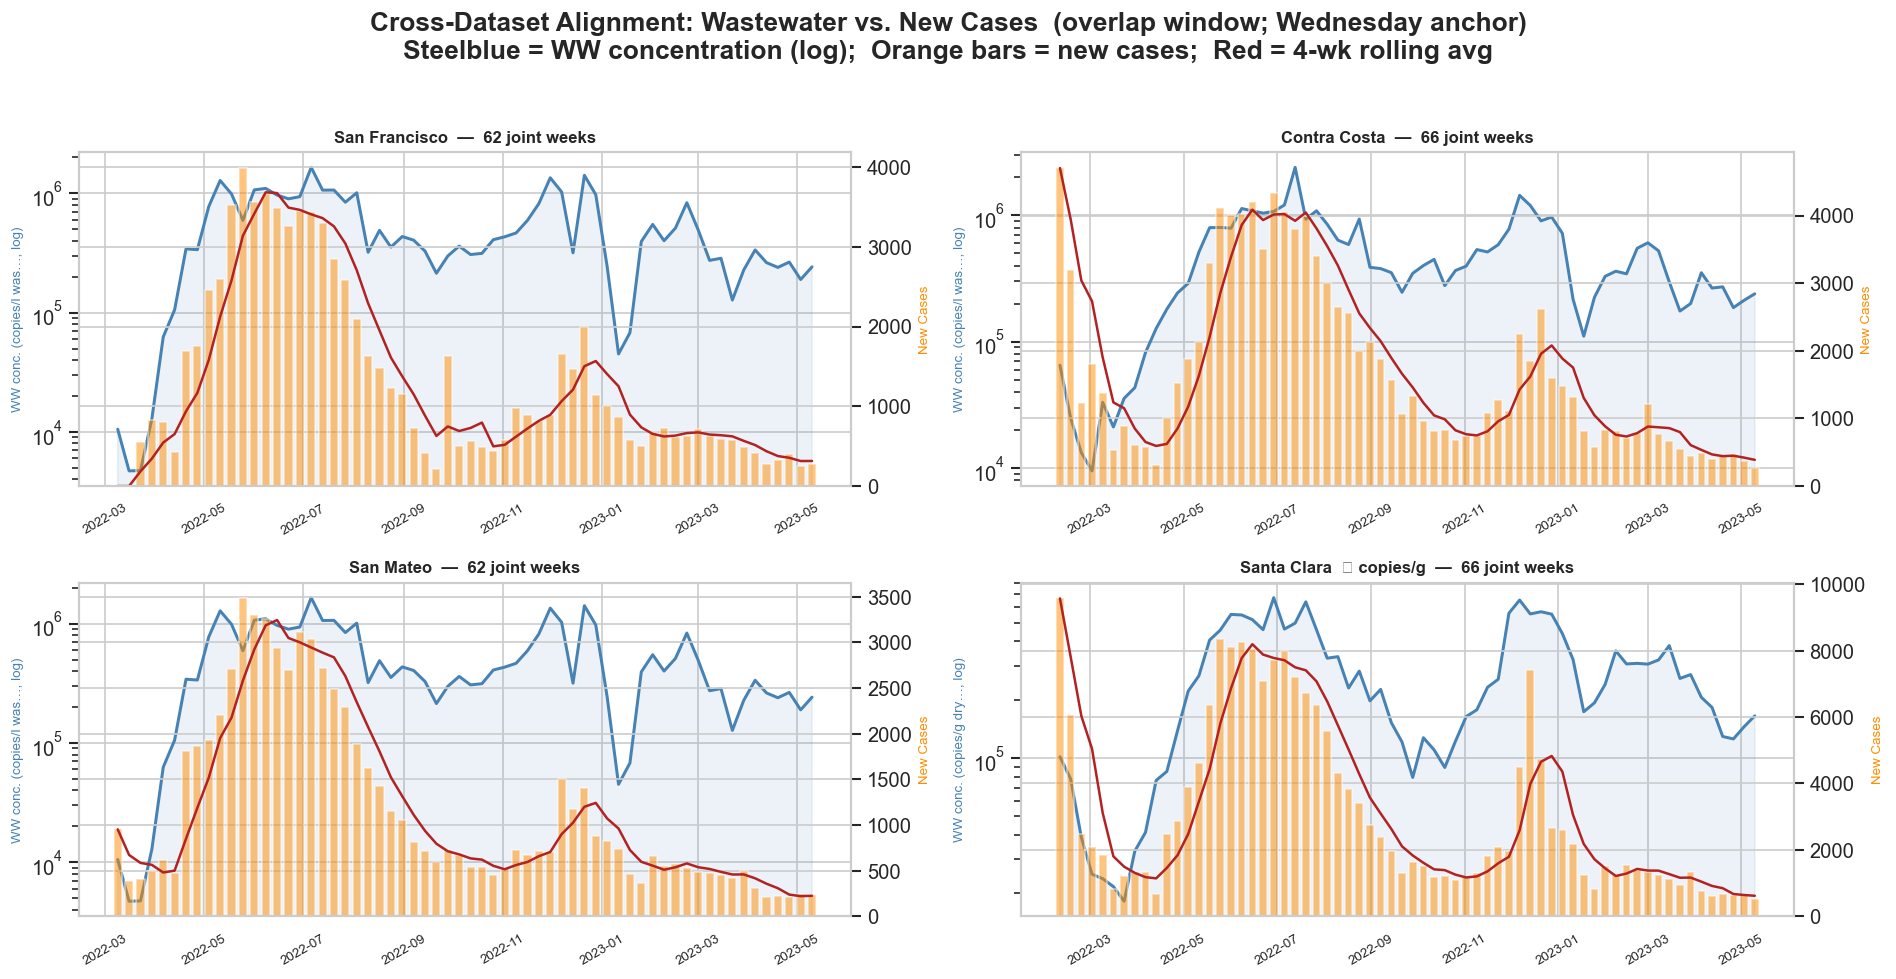


Joint weeks (overlap window, both signals present):
  San Francisco  :  62 joint weeks
  Contra Costa   :  66 joint weeks
  San Mateo      :  62 joint weeks
  Santa Clara    :  66 joint weeks


In [197]:
ILLUSTRATIVE = [
    ('06075', 'San Francisco',  'copies/l wastewater'),
    ('06013', 'Contra Costa',   'copies/l wastewater'),
    ('06081', 'San Mateo',      'copies/l wastewater'),
    ('06085', 'Santa Clara',    'copies/g dry sludge'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes_flat = axes.flatten()

for ax, (fips, name, unit) in zip(axes_flat, ILLUSTRATIVE):
    src_df = ww_sc_sludge if fips == '06085' else ww_bay_wwtp[ww_bay_wwtp['county_fips_list'] == fips]

    if len(src_df) == 0:
        ax.set_title(f'{name} — no WW data in dataset', fontsize=10)
        continue

    ww_county = (
        src_df
        .set_index('sample_collect_date')['pcr_target_avg_conc']
        .resample('W-WED').median().dropna()
        .reset_index()
        .rename(columns={'sample_collect_date': 'date', 'pcr_target_avg_conc': 'ww'})
    )

    cases_county = (
        cases_bay_ov[cases_bay_ov['fips_code'] == fips]
        .sort_values('date')[['date', 'new_cases']]
        .copy()
    )
    cases_county['cases_clipped'] = cases_county['new_cases'].clip(lower=0)

    merged = (
        pd.merge(ww_county, cases_county, on='date', how='inner')
        .query('@OVERLAP_START <= date <= @OVERLAP_END')
        .copy()
    )
    n_joint = len(merged.dropna(subset=['ww', 'cases_clipped']))

    ax2 = ax.twinx()
    ax.semilogy(merged['date'], merged['ww'],
                color='steelblue', lw=1.8, label=f'WW')
    ax.fill_between(merged['date'], merged['ww'], alpha=0.1, color='steelblue')
    ax.set_ylabel(f'WW conc. ({unit[:12]}…, log)', color='steelblue', fontsize=8)

    ax2.bar(merged['date'], merged['cases_clipped'],
            width=5, alpha=0.5, color='darkorange', label='New Cases')
    roll4 = merged['cases_clipped'].rolling(4, min_periods=1).mean()
    ax2.plot(merged['date'], roll4, color='firebrick', lw=1.5, label='4-wk avg')
    ax2.set_ylabel('New Cases', color='darkorange', fontsize=8)

    unit_note = '  ⚠ copies/g' if fips == '06085' else ''
    ax.set_title(
        f'{name}{unit_note}  —  {n_joint} joint weeks',
        fontsize=10, fontweight='bold',
    )
    ax.tick_params(axis='x', labelrotation=30, labelsize=8)

fig.suptitle(
    'Cross-Dataset Alignment: Wastewater vs. New Cases  (overlap window; Wednesday anchor)\n'
    'Steelblue = WW concentration (log);  Orange bars = new cases;  Red = 4-wk rolling avg',
    fontweight='bold', y=1.02,
)
plt.tight_layout()
plt.show()

print('\nJoint weeks (overlap window, both signals present):')
for fips, name, unit in ILLUSTRATIVE:
    src_df = ww_sc_sludge if fips == '06085' else ww_bay_wwtp[ww_bay_wwtp['county_fips_list'] == fips]
    ww_c = (src_df.set_index('sample_collect_date')['pcr_target_avg_conc']
            .resample('W-WED').median().rename('ww'))
    cs_c = (cases_bay_ov[cases_bay_ov['fips_code'] == fips]
            .set_index('date')['new_cases'].clip(lower=0).rename('cases'))
    merged = pd.concat([ww_c, cs_c], axis=1, join='inner').loc[OVERLAP_START:OVERLAP_END].dropna()
    print(f'  {name:15s}: {len(merged):3d} joint weeks')


### 5.4  Lead-time cross-correlation — all Bay Area counties

We compute the Pearson correlation between log-transformed wastewater concentration
and reported new COVID cases, sweeping lag *k* ∈ {−4, …, +8} weeks.
**Positive lag = wastewater leads cases** (the core project hypothesis).
Only county-weeks where **both** datasets have a valid observation are used.

Cross-correlation: log(WW copies/l) vs. new_cases (clipped)  |  overlap window  |  lag −4…+8 weeks
Positive lag = wastewater LEADS cases



,County,n_joint_wks,best_lag_wks,max_r,note
1,Contra Costa,66,2.0,0.518,
0,Alameda,66,1.0,0.475,
3,Napa,27,1.0,0.708,
7,Sonoma,52,1.0,0.781,
4,San Francisco,62,0.0,0.556,
5,San Mateo,62,0.0,0.503,
2,Marin,0,NaN,NaN,WW monitoring started post-overlap
6,Solano,0,NaN,NaN,WW monitoring started post-overlap


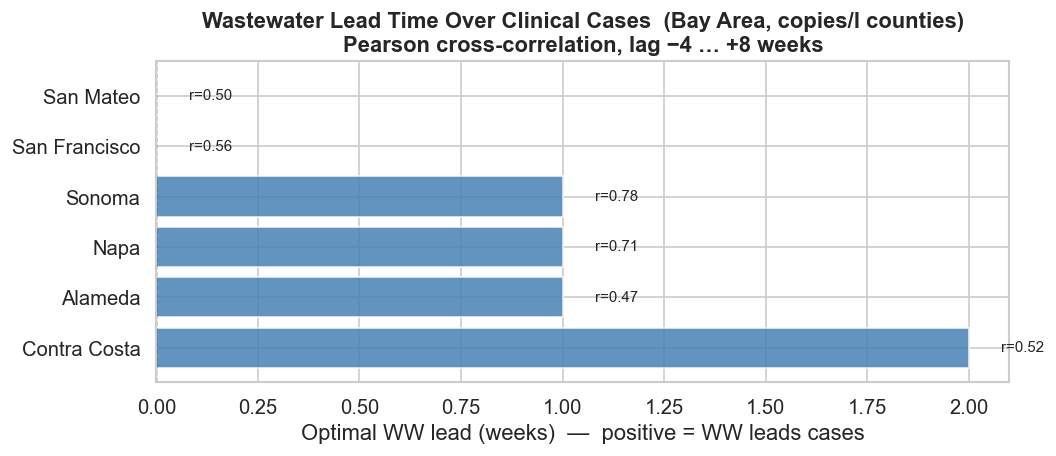

In [198]:
# Cross-correlation: log(WW concentration) vs. new_cases
# All 9 counties now have complete case data in the overlap window.
# Marin and Solano are still excluded: their WW monitoring began in 2024,
# after the cases archive ended.  Santa Clara uses copies/g sludge unit.

LAG_RANGE = range(-4, 9)
corr_rows = []
FIPS_COPIES_L = {f for f in BAY_FIPS_PADDED if f != '06085'}

for fips in sorted(FIPS_COPIES_L):
    name = FIPS_TO_NAME[fips]

    ww_c = (
        ww_bay_wwtp[ww_bay_wwtp['county_fips_list'] == fips]
        .set_index('sample_collect_date')['pcr_target_avg_conc']
        .resample('W-WED').median().rename('ww')
    )
    cs_c = (
        cases_bay_ov[cases_bay_ov['fips_code'] == fips]
        .set_index('date')['new_cases']
        .clip(lower=0).rename('cases')
    )

    aligned = (
        pd.concat([ww_c, cs_c], axis=1, join='inner')
        .loc[OVERLAP_START:OVERLAP_END]
        .dropna()
    )
    n = len(aligned)

    if n < 10:
        corr_rows.append({'County': name, 'n_joint_wks': n,
                          'best_lag_wks': None, 'max_r': None,
                          'note': 'WW monitoring started post-overlap'})
        continue

    x_all = np.log1p(aligned['ww'].values)
    y_all = aligned['cases'].values

    best_r, best_lag = -np.inf, 0
    for lag in LAG_RANGE:
        xv, yv = (x_all[:n-lag], y_all[lag:]) if lag >= 0 else (x_all[-lag:], y_all[:n+lag])
        if len(xv) < 8: continue
        r = float(np.corrcoef(xv, yv)[0, 1])
        if r > best_r: best_r, best_lag = r, lag

    corr_rows.append({'County': name, 'n_joint_wks': n,
                      'best_lag_wks': int(best_lag), 'max_r': round(best_r, 3), 'note': ''})

corr_df = pd.DataFrame(corr_rows).sort_values('best_lag_wks', ascending=False, na_position='last')
print('Cross-correlation: log(WW copies/l) vs. new_cases (clipped)  |  overlap window  |  lag −4…+8 weeks')
print('Positive lag = wastewater LEADS cases\n')
display(corr_df)

fig, ax = plt.subplots(figsize=(9, 4))
valid = corr_df.dropna(subset=['best_lag_wks','max_r'])
colors = ['steelblue' if l > 0 else '#aaaaaa' if l == 0 else 'salmon'
          for l in valid['best_lag_wks']]
bars = ax.barh(valid['County'], valid['best_lag_wks'], color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Optimal WW lead (weeks)  —  positive = WW leads cases')
ax.set_title('Wastewater Lead Time Over Clinical Cases  (Bay Area, copies/l counties)\n'
             'Pearson cross-correlation, lag −4 … +8 weeks', fontweight='bold')
for bar, r in zip(bars, valid['max_r']):
    xpos = bar.get_width()
    ax.text(xpos + (0.08 if xpos >= 0 else -0.08),
            bar.get_y() + bar.get_height()/2,
            f'r={r:.2f}', va='center',
            ha='left' if xpos >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()


---
## 6  EDA Summary & Modelling Implications

### 6.1  Key findings

| Topic | Finding | Implication for TFT + PINN |
|-------|---------|---------------------------|
| **Unit heterogeneity** | Bay Area = 8 counties in `copies/l`; Santa Clara in `copies/g dry sludge` | Two parallel pipelines — never mix units; log-normalise each separately |
| **Date anchor — cases** | CDC spine is Wednesday-anchored; perfectly regular 7-day gaps | Resample WW to `W-WED` before any join to eliminate the 1-day systematic offset |
| **Missing case counts** | 3.5 % – 66 % of weeks missing `new_cases` per county | CDC missingness is not zero — use `new_cases_reported` flag; do not impute |
| **Log-normal concentration** | log₁₀ concentration is approximately Gaussian | Use `log1p` as the TFT target; RobustScaler fitted on training data only |
| **Growth rate distribution** | Realistic weekly growth rarely exceeds 200-300 %; pandemic peaks ~500 % | PINN threshold of `MAX_DAILY × 7 = 245 %` per step is empirically motivated |
| **Recovery efficiency** | Small fraction of samples have rec_eff < 10 % | Drop rec_eff < 10 % samples before aggregation (processor QC gate) |
| **Inhibition artifacts** | Inhibited samples show lower concentration | Flag `inhibition_detect = yes`; down-weight in population-weighted aggregation |
| **Multi-county WWTP sites** | Some sites serve multiple counties | Explode to per-county rows; population-weighted attribution |
| **Sampling gaps** | Gaps > 30 d exist at site level; weekly resampled signal is smoother | Center 7-day smoothing, then resample to weekly; gap-flag feature for lag windows |
| **Wastewater lead time** | SF and Napa show 1-week WW lead over cases (Pearson cross-correlation) | TFT horizon h = 4 weeks; lag features up to 3 weeks back are informative |
| **Population heterogeneity** | Sites range from 50k to 2M population served | `log_population` as static covariate; population-weighted county aggregation |
| **Marin / Solano WW** | WW data for these counties begins 2024 (post-cases archive) | Exclude from cross-dataset correlation; include in WW-only forecasting |

### 6.2  Variables the TFT must attend to

| Variable | Role | Engineering step |
|----------|------|-----------------|
| `log1p_concentration` | Target `y` | log1p after population-weighted aggregation |
| `log1p_concentration_lag{1,2,3}w` | Historical covariate | Leakage-free lag features |
| `growth_rate_1w` | Historical covariate | `(y_t − y_{t−1}) / (y_{t−1} + ε)` |
| `outlier_flag_int` | Historical covariate | IQR flag → {0, 1} |
| `sin/cos_annual_{1,2,3}` | Future covariate | Fourier seasonality |
| `day_of_week_sin/cos` | Future covariate | Within-week reporting pattern |
| `month_sin/cos`, `week_of_year` | Future covariate | Monthly / ISO-week seasonality |
| `log_population` | Static covariate | log1p(median population served per county) |
| `county_fips_encoded` | Static covariate | Integer ID per county |

### 6.3  PINN constraint calibration

The growth-rate penalty fires when the median-quantile step rate exceeds
`MAX_DAILY_GROWTH_RATE × 7 = 2.45` (i.e. 245 % per weekly step).  The
cross-correlation analysis shows that realised wastewater peaks during pandemic
waves correspond to 3–7× growth over 4–8 weeks — the threshold allows for rapid
but biologically plausible surges while suppressing artefactual single-step jumps.